# Riemannian geometry for EEG BCI

## From brain signals to decisions, one concept at a time

This notebook turns the ideas from the theory webpage into a complete,
reproducible motor-imagery BCI example. Allow about 30–45 minutes to
read and run it. You can execute each section in order; every code cell
starts with its purpose, and every figure ends with one takeaway.

We will compare three complete ways to classify a short EEG trial:

1. **CSP + LDA** — a strong, classical motor-imagery baseline.
2. **Riemannian MDM** — compare each covariance matrix with the average
   matrix of each class.
3. **Tangent space + logistic regression** — temporarily map the curved
   covariance space to ordinary coordinates, then use a standard
   classifier.

We will also add one deliberately plain diagnostic baseline: a
**Euclidean covariance nearest-mean** classifier. It uses covariance
matrices, but it ignores the curved SPD geometry. That contrast makes
the advantage of the Riemannian distance visible rather than rhetorical.

The goal is not to prove that one method always wins. The goal is to
understand what the geometric representation adds, when it helps, and
how to use it without data leakage.

## What you should be able to explain afterward

- What an EEG trial, channel, and motor-imagery cue mean.
- Why a covariance matrix is a useful summary of a multichannel trial.
- Why valid covariance matrices do not fill an ordinary flat space.
- How the Riemannian distance turns eigenvalue ratios into a
  scale-aware distance.
- How minimum distance to mean (MDM) makes a prediction.
- What a tangent-space representation is used for.
- How to separate "covariance helped" from "Riemannian geometry helped."
- Why complete recording runs must be held out during validation.
- Why a method can be useful even when its final accuracy ties a
  classical baseline.

> **Vocabulary rule used here:** each technical term is defined before
> it becomes part of the workflow.

## The dataset: imagined movement recorded with EEG

We use the open **PhysioNet EEG Motor Movement/Imagery Dataset** through
MNE-Python.

- **EEG channel:** one voltage measurement location on the scalp.
- **Trial:** a short recording aligned to one instruction.
- **Motor imagery:** imagining a movement without physically performing
  it.
- **Class:** the instruction we want the computer to identify.

The selected runs ask one participant to imagine moving both hands or
both feet. The original recordings contain 64 channels sampled at
160 Hz. We retain 17 channels over the motor cortex to keep every figure
readable.

This is a teaching dataset, not a clinical benchmark. The default
download is about 7.4 MB and contains only one participant.

**Why use MNE's direct loader here?** It keeps this first run small and
depends only on the analysis stack used later. EEGDash offers a
BIDS-first catalogue and loader for scaling to other datasets; an
optional, tested discovery snippet appears in the final section.

## Environment setup

Run the next two cells once before the imports.

- In **Google Colab**, they install the missing analysis packages and
  create the helper module inside the runtime.
- In the local `rnd_env` environment, they usually report that
  everything is already available and keep using the tracked helper file.

This makes the notebook self-contained when opened from Drive/Colab
while preserving the reproducible local `rnd_env` workflow.

In [1]:
# Purpose: Install missing packages when running in Colab or a fresh Python runtime.

import importlib.util
import subprocess
import sys

requirements = {
    "mne": "mne==1.12.1",
    "pyriemann": "pyriemann==0.10",
    "sklearn": "scikit-learn>=1.7",
    "pandas": "pandas>=2.2",
    "seaborn": "seaborn>=0.13",
}
missing = [
    package
    for module, package in requirements.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing]
    )
    print("Installed:", ", ".join(missing))
else:
    print("All required analysis packages are already available.")

All required analysis packages are already available.


In [2]:
# Purpose: Create or locate the helper module so the notebook is self-contained.

from pathlib import Path
import sys

candidate_paths = [
    Path.cwd() / "riemannian_eeg_utils.py",
    Path.cwd() / "notebooks" / "riemannian_eeg_utils.py",
]
helper_path = next((path for path in candidate_paths if path.exists()), candidate_paths[0])
if helper_path.exists():
    print(f"Using helper module at {helper_path}")
else:
    helper_path.write_text('"""Utilities for the educational Riemannian EEG notebook.\n\nThe functions intentionally keep the workflow explicit. They are not intended\nto replace a production preprocessing or model-selection pipeline.\n"""\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass\nfrom pathlib import Path\nfrom typing import Iterable\nimport warnings\n\nimport mne\nimport numpy as np\nimport pandas as pd\nfrom mne.channels import make_standard_montage\nfrom mne.datasets import eegbci\nfrom mne.decoding import CSP\nfrom mne.io import read_raw_edf\nfrom pyriemann.classification import MDM\nfrom pyriemann.estimation import Covariances\nfrom pyriemann.tangentspace import TangentSpace\nfrom sklearn.base import BaseEstimator, ClassifierMixin, clone\nfrom sklearn.discriminant_analysis import LinearDiscriminantAnalysis\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.metrics import accuracy_score, balanced_accuracy_score\nfrom sklearn.model_selection import LeaveOneGroupOut\nfrom sklearn.pipeline import Pipeline\n\n\nDEFAULT_CHANNELS = (\n    "FC5",\n    "FC3",\n    "FC1",\n    "FCz",\n    "FC2",\n    "FC4",\n    "FC6",\n    "C5",\n    "C3",\n    "C1",\n    "Cz",\n    "C2",\n    "C4",\n    "C6",\n    "CP3",\n    "CPz",\n    "CP4",\n)\n\nCLASS_NAMES = np.array(["hands", "feet"])\n\n\nclass EuclideanCovarianceNearestMean(BaseEstimator, ClassifierMixin):\n    """Nearest class mean classifier using flat Frobenius matrix distance.\n\n    This intentionally treats covariance matrices as ordinary Euclidean arrays.\n    The notebook uses it as a diagnostic contrast against Riemannian MDM, not as\n    a recommended default.\n    """\n\n    def fit(self, X: np.ndarray, y: np.ndarray) -> "EuclideanCovarianceNearestMean":\n        self.classes_ = np.unique(y)\n        self.means_ = np.stack(\n            [X[y == class_id].mean(axis=0) for class_id in self.classes_]\n        )\n        return self\n\n    def predict(self, X: np.ndarray) -> np.ndarray:\n        distances = np.linalg.norm(\n            X[:, np.newaxis, :, :] - self.means_[np.newaxis, :, :, :],\n            axis=(-2, -1),\n        )\n        return self.classes_[np.argmin(distances, axis=1)]\n\n\n@dataclass\nclass MotorImageryDataset:\n    """Container returned by :func:`load_motor_imagery`."""\n\n    epochs: mne.Epochs\n    X: np.ndarray\n    y: np.ndarray\n    groups: np.ndarray\n    metadata: pd.DataFrame\n    channel_names: list[str]\n    sfreq: float\n\n\ndef load_motor_imagery(\n    *,\n    subjects: Iterable[int] = (1,),\n    runs: Iterable[int] = (6, 10, 14),\n    data_path: str | Path = "../data/mne",\n    channels: Iterable[str] = DEFAULT_CHANNELS,\n    l_freq: float = 8.0,\n    h_freq: float = 30.0,\n    tmin: float = 1.0,\n    tmax: float = 3.0,\n    verbose: bool | str = False,\n) -> MotorImageryDataset:\n    """Download, filter, and epoch PhysioNet EEGBCI motor-imagery data.\n\n    Runs 6, 10, and 14 contain imagined movement of both hands versus both\n    feet. Each subject-run pair becomes one validation group.\n    """\n\n    subjects = tuple(subjects)\n    runs = tuple(runs)\n    channels = tuple(channels)\n    data_path = Path(data_path).expanduser().resolve()\n    data_path.mkdir(parents=True, exist_ok=True)\n    montage = make_standard_montage("standard_1005")\n\n    all_epochs: list[mne.Epochs] = []\n    group_values: list[int] = []\n    metadata_rows: list[dict[str, int | str]] = []\n    group_id = 0\n\n    for subject in subjects:\n        file_paths = eegbci.load_data(\n            subject,\n            runs,\n            path=data_path,\n            update_path=False,\n            verbose=verbose,\n        )\n        for run, file_path in zip(runs, file_paths, strict=True):\n            raw = read_raw_edf(file_path, preload=True, verbose=verbose)\n            eegbci.standardize(raw)\n            raw.set_montage(montage, on_missing="ignore", verbose=verbose)\n            missing = sorted(set(channels) - set(raw.ch_names))\n            if missing:\n                raise ValueError(f"Requested channels missing from EEGBCI data: {missing}")\n            raw.pick(channels)\n            raw.annotations.rename({"T1": "hands", "T2": "feet"})\n            raw.set_eeg_reference("average", projection=False, verbose=verbose)\n            raw.filter(\n                l_freq,\n                h_freq,\n                fir_design="firwin",\n                skip_by_annotation="edge",\n                verbose=verbose,\n            )\n\n            epochs = mne.Epochs(\n                raw,\n                event_id=["hands", "feet"],\n                tmin=tmin,\n                tmax=tmax,\n                baseline=None,\n                preload=True,\n                reject_by_annotation=True,\n                verbose=verbose,\n            )\n            all_epochs.append(epochs)\n\n            inverse_event_id = {\n                value: name for name, value in epochs.event_id.items()\n            }\n            for trial_index, event_code in enumerate(epochs.events[:, -1]):\n                label_name = inverse_event_id[int(event_code)]\n                metadata_rows.append(\n                    {\n                        "subject": subject,\n                        "run": run,\n                        "trial": trial_index,\n                        "condition": label_name,\n                    }\n                )\n                group_values.append(group_id)\n            group_id += 1\n\n    with warnings.catch_warnings():\n        warnings.filterwarnings(\n            "ignore",\n            message="Concatenation of Annotations within Epochs is not supported",\n        )\n        combined = mne.concatenate_epochs(\n            all_epochs,\n            on_mismatch="warn",\n            verbose=verbose,\n        )\n    metadata = pd.DataFrame(metadata_rows)\n    y = metadata["condition"].map({"hands": 0, "feet": 1}).to_numpy(dtype=int)\n    groups = np.asarray(group_values, dtype=int)\n\n    return MotorImageryDataset(\n        epochs=combined,\n        X=combined.get_data(copy=True),\n        y=y,\n        groups=groups,\n        metadata=metadata,\n        channel_names=list(combined.ch_names),\n        sfreq=float(combined.info["sfreq"]),\n    )\n\n\ndef build_pipelines(random_state: int = 42) -> dict[str, Pipeline]:\n    """Create three educational decoding pipelines."""\n\n    return {\n        "CSP + LDA": Pipeline(\n            [\n                (\n                    "csp",\n                    CSP(\n                        n_components=6,\n                        reg="ledoit_wolf",\n                        log=True,\n                        norm_trace=False,\n                    ),\n                ),\n                (\n                    "lda",\n                    LinearDiscriminantAnalysis(\n                        solver="lsqr",\n                        shrinkage="auto",\n                    ),\n                ),\n            ]\n        ),\n        "Riemannian MDM": Pipeline(\n            [\n                ("covariance", Covariances(estimator="oas")),\n                ("classifier", MDM(metric="riemann")),\n            ]\n        ),\n        "Tangent space + logistic regression": Pipeline(\n            [\n                ("covariance", Covariances(estimator="oas")),\n                ("tangent", TangentSpace(metric="riemann")),\n                (\n                    "classifier",\n                    LogisticRegression(\n                        max_iter=2_000,\n                        class_weight="balanced",\n                        random_state=random_state,\n                    ),\n                ),\n            ]\n        ),\n    }\n\n\ndef build_geometry_contrast_pipelines() -> dict[str, Pipeline]:\n    """Create covariance nearest-mean pipelines that differ only by geometry."""\n\n    return {\n        "Euclidean covariance mean": Pipeline(\n            [\n                ("covariance", Covariances(estimator="oas")),\n                ("classifier", EuclideanCovarianceNearestMean()),\n            ]\n        ),\n        "Riemannian MDM": Pipeline(\n            [\n                ("covariance", Covariances(estimator="oas")),\n                ("classifier", MDM(metric="riemann")),\n            ]\n        ),\n    }\n\n\ndef evaluate_leave_one_group_out(\n    pipelines: dict[str, Pipeline],\n    X: np.ndarray,\n    y: np.ndarray,\n    groups: np.ndarray,\n) -> tuple[pd.DataFrame, pd.DataFrame]:\n    """Evaluate each pipeline with one held-out subject-run group."""\n\n    splitter = LeaveOneGroupOut()\n    score_rows: list[dict[str, float | int | str]] = []\n    prediction_rows: list[dict[str, int | str]] = []\n\n    for fold, (train, test) in enumerate(splitter.split(X, y, groups), start=1):\n        held_out_group = int(np.unique(groups[test]).item())\n        for model_name, pipeline in pipelines.items():\n            estimator = clone(pipeline)\n            estimator.fit(X[train], y[train])\n            predictions = estimator.predict(X[test])\n\n            score_rows.append(\n                {\n                    "model": model_name,\n                    "fold": fold,\n                    "held_out_group": held_out_group,\n                    "accuracy": accuracy_score(y[test], predictions),\n                    "balanced_accuracy": balanced_accuracy_score(\n                        y[test],\n                        predictions,\n                    ),\n                    "n_train": len(train),\n                    "n_test": len(test),\n                }\n            )\n            prediction_rows.extend(\n                {\n                    "model": model_name,\n                    "fold": fold,\n                    "held_out_group": held_out_group,\n                    "truth": int(truth),\n                    "prediction": int(prediction),\n                }\n                for truth, prediction in zip(y[test], predictions, strict=True)\n            )\n\n    return pd.DataFrame(score_rows), pd.DataFrame(prediction_rows)\n\n\ndef evaluate_low_data_regime(\n    pipelines: dict[str, Pipeline],\n    X: np.ndarray,\n    y: np.ndarray,\n    groups: np.ndarray,\n    *,\n    trials_per_class: Iterable[int] = (2, 4, 6, 10),\n    repeats: int = 10,\n    random_state: int = 42,\n) -> pd.DataFrame:\n    """Measure performance when only a few calibration trials are available."""\n\n    rng = np.random.default_rng(random_state)\n    splitter = LeaveOneGroupOut()\n    rows: list[dict[str, float | int | str]] = []\n\n    for fold, (train, test) in enumerate(splitter.split(X, y, groups), start=1):\n        for n_trials in trials_per_class:\n            for repeat in range(repeats):\n                sampled = np.concatenate(\n                    [\n                        rng.choice(\n                            train[y[train] == class_id],\n                            size=min(\n                                n_trials,\n                                int(np.sum(y[train] == class_id)),\n                            ),\n                            replace=False,\n                        )\n                        for class_id in np.unique(y)\n                    ]\n                )\n                for model_name, pipeline in pipelines.items():\n                    estimator = clone(pipeline)\n                    with mne.use_log_level("ERROR"):\n                        estimator.fit(X[sampled], y[sampled])\n                    predictions = estimator.predict(X[test])\n                    rows.append(\n                        {\n                            "model": model_name,\n                            "fold": fold,\n                            "repeat": repeat,\n                            "trials_per_class": n_trials,\n                            "balanced_accuracy": balanced_accuracy_score(\n                                y[test],\n                                predictions,\n                            ),\n                        }\n                    )\n\n    return pd.DataFrame(rows)\n', encoding="utf-8")
    print(f"Created helper module at {helper_path}")

sys.path.insert(0, str(helper_path.parent))

Using helper module at /Users/itamaravitan/Library/CloudStorage/OneDrive-post.bgu.ac.il/PhD/Courses/נוירוטכנולוגיה/notebooks/riemannian_eeg_utils.py


In [3]:
# Purpose: Import the analysis tools, define project paths, and report versions.

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pyriemann
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from matplotlib.patches import Ellipse
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from pyriemann.utils.distance import distance_riemann
from pyriemann.utils.geodesic import geodesic_riemann
from pyriemann.utils.mean import mean_riemann
from scipy.signal import welch
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import LeaveOneGroupOut

# Work whether Jupyter starts in the project root or notebooks folder.
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "riemannian_eeg_utils.py").exists():
    NOTEBOOK_DIR = Path.cwd() / "notebooks"
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    # Colab usually runs from /content with the helper module created
    # in the current directory; keep data/figures under that writable
    # workspace instead of resolving to /data.
    PROJECT_ROOT = NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "mne"
FIGURE_PATH = NOTEBOOK_DIR / "figures"
FIGURE_PATH.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(NOTEBOOK_DIR))

from riemannian_eeg_utils import (
    CLASS_NAMES,
    build_geometry_contrast_pipelines,
    build_pipelines,
    evaluate_leave_one_group_out,
    evaluate_low_data_regime,
    load_motor_imagery,
)

mne.set_log_level("ERROR")
sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette=["#5b47f5", "#e75e9b", "#18a999"],
)
plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "figure.dpi": 110,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

versions = pd.Series(
    {
        "MNE": mne.__version__,
        "pyRiemann": pyriemann.__version__,
        "scikit-learn": sklearn.__version__,
        "NumPy": np.__version__,
    },
    name="version",
)
display(versions.to_frame())

,version
MNE,1.12.1
pyRiemann,0.10
scikit-learn,1.7.2
NumPy,2.3.5


## 0. A visible two-channel example

Before loading real EEG, reproduce the two website lessons with matrices
small enough to draw.

Pattern A and Pattern B are covariance summaries of two hypothetical
trials. Both have the same determinant and therefore the same relative
ellipse area, but different channels dominate.

The decoder needs operations between these observed patterns:

- a **path** defines what intermediate matrices mean;
- the path length defines **distance**;
- distance defines the **center** of a set of training matrices;
- class centers are used by MDM to predict a new trial.

> **Predict first.** Pattern A and Pattern B are equally strong, but different channels dominate. If you average the two matrices entry by entry, how strong is the result?
>
- stronger than either one
- exactly as strong as both
- weaker than either one
>
> <details><summary>Commit to one, then open this.</summary>
>
> Stronger. Entry-wise averaging invents variation that neither trial contained -- the determinant of the midpoint exceeds both endpoints. The assertion in the next cell checks exactly this.
>
> </details>

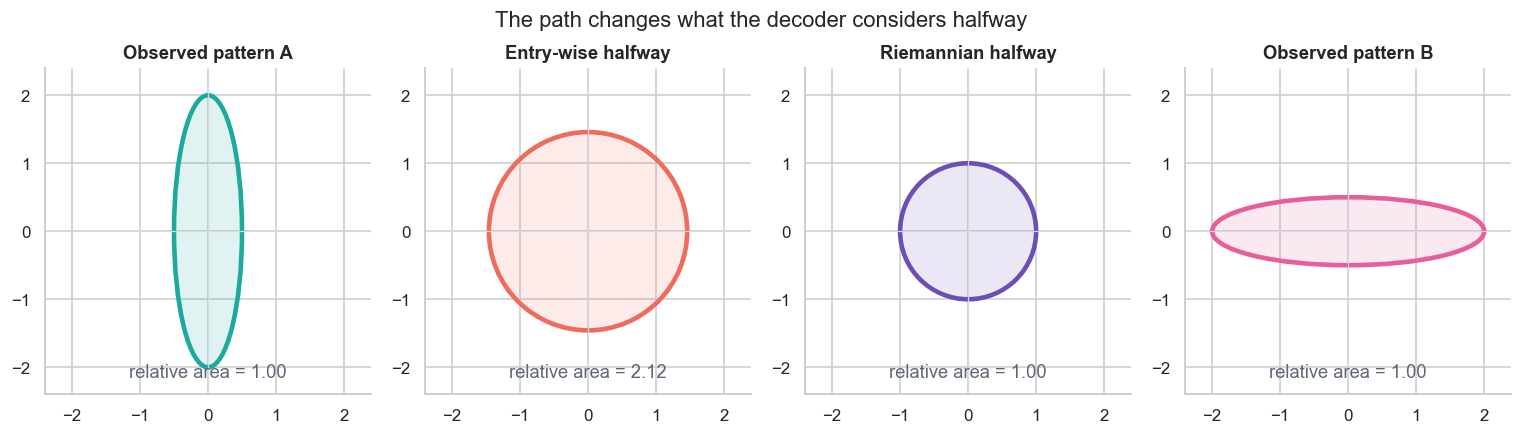

> **Figure takeaway:** the entry-wise midpoint invents scale in this example, while the Riemannian midpoint preserves the endpoints' relative area.

In [4]:
# Purpose: Reproduce the website's two routes between covariance patterns.

toy_a = np.diag([0.25, 4.0])
toy_b = np.diag([4.0, 0.25])
entry_midpoint = 0.5 * (toy_a + toy_b)
riemannian_midpoint = geodesic_riemann(toy_a, toy_b, alpha=0.5)


def draw_covariance_ellipse(axis, covariance, title, color):
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse = Ellipse(
        (0, 0),
        width=2 * np.sqrt(eigenvalues[0]),
        height=2 * np.sqrt(eigenvalues[1]),
        angle=angle,
        facecolor=f"{color}22",
        edgecolor=color,
        linewidth=3,
    )
    axis.add_patch(ellipse)
    axis.axhline(0, color="#d7d9e2", linewidth=0.8)
    axis.axvline(0, color="#d7d9e2", linewidth=0.8)
    axis.set(xlim=(-2.4, 2.4), ylim=(-2.4, 2.4), aspect="equal", title=title)
    axis.text(
        0,
        -2.15,
        f"relative area = {np.sqrt(np.linalg.det(covariance)):.2f}",
        ha="center",
        color="#5f6677",
    )


fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
examples = [
    (toy_a, "Observed pattern A", "#1ca9a0"),
    (entry_midpoint, "Entry-wise halfway", "#ef6b5b"),
    (riemannian_midpoint, "Riemannian halfway", "#6c4eb9"),
    (toy_b, "Observed pattern B", "#e75e9b"),
]
for axis, (matrix, title, color) in zip(axes, examples, strict=True):
    draw_covariance_ellipse(axis, matrix, title, color)
fig.suptitle("The path changes what the decoder considers halfway")
fig.tight_layout()
plt.show()
display(Markdown(
    "> **Figure takeaway:** the entry-wise midpoint invents scale in "
    "this example, while the Riemannian midpoint preserves the "
    "endpoints' relative area."
))

assert np.isclose(np.sqrt(np.linalg.det(toy_a)), 1.0)
assert np.sqrt(np.linalg.det(entry_midpoint)) > 2.0
assert np.isclose(np.sqrt(np.linalg.det(riemannian_midpoint)), 1.0)

### The geometry in one equation

For two SPD covariance matrices \(C_1\) and \(C_2\), the
affine-invariant Riemannian distance used by pyRiemann is

\[
d_R(C_1,C_2) =
\left\|\log\left(C_1^{-1/2}C_2C_1^{-1/2}\right)\right\|_F.
\]

Read this as three operations:

1. use \(C_1^{-1/2}\) to express \(C_2\) relative to \(C_1\);
2. take eigenvalue ratios of that relative transformation;
3. measure the size of their logarithms.

So the geometry compares **multiplicative changes in variance**, not raw
entry differences. That matters for EEG because covariance scale can
change with electrodes, referencing, sessions, or user state.

> **Predict first.** Further down this cell you will mix the two channels
> together with an invertible matrix — the algebra of switching your
> reference montage, or of the skull smearing sources across electrodes.
> The brain has not changed. Which distances move?
>
- both the Euclidean and the Riemannian one
- the Euclidean one only
- neither of them
>
> <details><summary>Commit to one, then open this.</summary>
>
> The Euclidean one only, and by a lot — over 500% for the gain case and
> about 38% for the mixing case. The Riemannian distance is unchanged to
> every decimal shown, because it is *defined* to be blind to exactly
> this family of transformations. That single property is why the method
> suits EEG, and the assertion at the end of the cell enforces it.
>
> </details>

,quantity,value
0,relative eigenvalue 1,0.062
1,relative eigenvalue 2,16.000
2,log relative eigenvalue 1,-2.773
3,log relative eigenvalue 2,2.773
4,Euclidean Frobenius distance,5.303
5,Riemannian distance,3.921


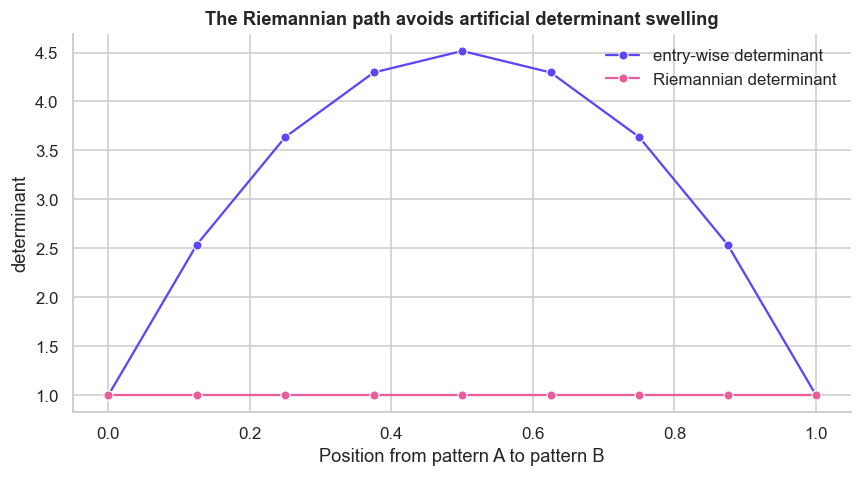

,recording change,Euclidean before,Euclidean after,Riemannian before,Riemannian after
0,per-channel gain,5.303,33.755,3.921,3.921
1,channel mixing,5.303,7.300,3.921,3.921


> **Math takeaway:** the Riemannian distance is unchanged by *any* invertible mixing of the channels, not just by rescaling them one at a time. That matters because the mixing case is the realistic one: volume conduction through the skull, a change of reference montage, and a different electrode montage all mix channels into each other. The Euclidean distance moves under both. This single property is the main reason the geometry suits EEG covariance matrices.

In [5]:
# Purpose: Break down the Riemannian distance and show it survives any invertible mixing of the channels.

def matrix_inverse_sqrt(matrix):
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    return eigenvectors @ np.diag(1 / np.sqrt(eigenvalues)) @ eigenvectors.T


relative_transform = (
    matrix_inverse_sqrt(toy_a) @ toy_b @ matrix_inverse_sqrt(toy_a)
)
relative_eigenvalues = np.linalg.eigvalsh(relative_transform)

distance_breakdown = pd.DataFrame(
    {
        "quantity": [
            "relative eigenvalue 1",
            "relative eigenvalue 2",
            "log relative eigenvalue 1",
            "log relative eigenvalue 2",
            "Euclidean Frobenius distance",
            "Riemannian distance",
        ],
        "value": [
            relative_eigenvalues[0],
            relative_eigenvalues[1],
            np.log(relative_eigenvalues[0]),
            np.log(relative_eigenvalues[1]),
            np.linalg.norm(toy_a - toy_b, ord="fro"),
            distance_riemann(toy_a, toy_b),
        ],
    }
)
display(distance_breakdown.style.format({"value": "{:.3f}"}))

t_values = np.linspace(0, 1, 9)
path_determinants = pd.DataFrame(
    {
        "path position": t_values,
        "entry-wise determinant": [
            np.linalg.det((1 - t) * toy_a + t * toy_b) for t in t_values
        ],
        "Riemannian determinant": [
            np.linalg.det(geodesic_riemann(toy_a, toy_b, alpha=t))
            for t in t_values
        ],
    }
)

fig, axis = plt.subplots(figsize=(8, 4.5))
sns.lineplot(
    data=path_determinants.melt(
        id_vars="path position",
        var_name="path",
        value_name="determinant",
    ),
    x="path position",
    y="determinant",
    hue="path",
    marker="o",
    ax=axis,
)
axis.set(
    xlabel="Position from pattern A to pattern B",
    ylabel="determinant",
    title="The Riemannian path avoids artificial determinant swelling",
)
axis.legend(frameon=False)
fig.tight_layout()
plt.show()

# Two kinds of recording change. Both are congruences C -> W C W^T;
# only the second one is what actually happens to EEG.
channel_gain = np.diag([3.0, 0.4])            # per-channel gain only
volume_conduction = np.array([[1.2, 0.7],     # a full, invertible mix
                              [-0.4, 0.9]])

def congruence(mixing, matrix):
    return mixing @ matrix @ mixing.T

rows = []
for label, mixing in [
    ("per-channel gain", channel_gain),
    ("channel mixing", volume_conduction),
]:
    mixed_a = congruence(mixing, toy_a)
    mixed_b = congruence(mixing, toy_b)
    rows.append({
        "recording change": label,
        "Euclidean before": np.linalg.norm(toy_a - toy_b, ord="fro"),
        "Euclidean after": np.linalg.norm(mixed_a - mixed_b, ord="fro"),
        "Riemannian before": distance_riemann(toy_a, toy_b),
        "Riemannian after": distance_riemann(mixed_a, mixed_b),
    })

invariance_check = pd.DataFrame(rows)
display(invariance_check.style.format({
    "Euclidean before": "{:.3f}",
    "Euclidean after": "{:.3f}",
    "Riemannian before": "{:.3f}",
    "Riemannian after": "{:.3f}",
}))
display(Markdown(
    "> **Math takeaway:** the Riemannian distance is unchanged by "
    "*any* invertible mixing of the channels, not just by rescaling "
    "them one at a time. That matters because the mixing case is the "
    "realistic one: volume conduction through the skull, a change of "
    "reference montage, and a different electrode montage all mix "
    "channels into each other. The Euclidean distance moves under "
    "both. This single property is the main reason the geometry suits "
    "EEG covariance matrices."
))

# Invariance holds for every invertible mixing, so assert it on both.
for mixing in (channel_gain, volume_conduction):
    assert np.isclose(
        distance_riemann(toy_a, toy_b),
        distance_riemann(
            congruence(mixing, toy_a), congruence(mixing, toy_b)
        ),
    )

The entry-wise midpoint is still a valid positive-definite covariance
matrix. The issue is not validity: its scale has grown beyond both
endpoints. This is the **swelling effect**.

Now use the same Riemannian distance to define a class center. The
Riemannian mean is the candidate with the smallest sum of squared
Riemannian distances to all training matrices.

,candidate,relative ellipse area,total squared Riemannian distance
0,Arithmetic center,1.489,6.248
1,Riemannian center,1.000,5.285


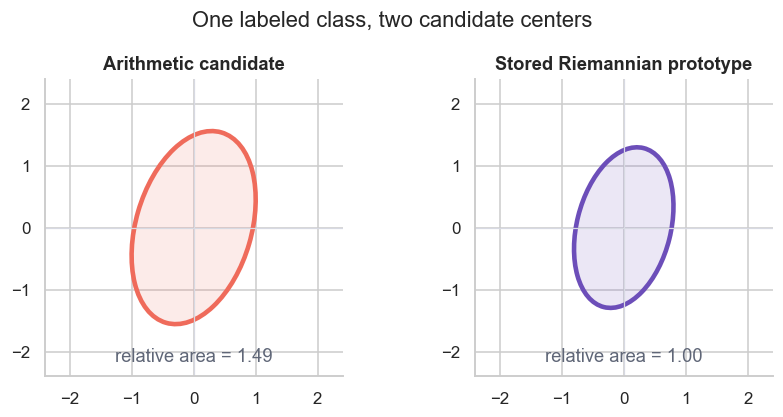

> **Figure takeaway:** the stored prototype is the valid matrix that best centers these trials under the same curved-space distance used for prediction.

In [6]:
# Purpose: Compare candidate class centers using the Riemannian objective.

def rotate(matrix, degrees):
    """Turn a pattern without changing how strong it is."""
    angle = np.deg2rad(degrees)
    rotation = np.array(
        [
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle), np.cos(angle)],
        ]
    )
    return rotation @ matrix @ rotation.T

# Note the third trial is TILTED. Up to here every toy matrix has been
# diagonal, and diagonal matrices commute -- on that slice the
# affine-invariant geometry collapses into element-wise log arithmetic
# and nothing distinguishes it. The moment one pattern is rotated the
# matrices stop commuting, and the real geometry has to do work.
toy_trials = np.stack(
    [
        np.diag([0.25, 4.0]),
        np.diag([0.5, 2.0]),
        rotate(np.diag([3.2, 1 / 3.2]), 35),
    ]
)
arithmetic_center = toy_trials.mean(axis=0)
riemannian_center = mean_riemann(toy_trials)


def total_squared_riemannian_distance(center, matrices):
    return sum(distance_riemann(center, matrix) ** 2 for matrix in matrices)


center_comparison = pd.DataFrame(
    {
        "candidate": ["Arithmetic center", "Riemannian center"],
        "relative ellipse area": [
            np.sqrt(np.linalg.det(arithmetic_center)),
            np.sqrt(np.linalg.det(riemannian_center)),
        ],
        "total squared Riemannian distance": [
            total_squared_riemannian_distance(arithmetic_center, toy_trials),
            total_squared_riemannian_distance(riemannian_center, toy_trials),
        ],
    }
)
display(center_comparison.style.format(
    {
        "relative ellipse area": "{:.3f}",
        "total squared Riemannian distance": "{:.3f}",
    }
))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
draw_covariance_ellipse(
    axes[0], arithmetic_center, "Arithmetic candidate", "#ef6b5b"
)
draw_covariance_ellipse(
    axes[1], riemannian_center, "Stored Riemannian prototype", "#6c4eb9"
)
fig.suptitle("One labeled class, two candidate centers")
fig.tight_layout()
plt.show()
display(Markdown(
    "> **Figure takeaway:** the stored prototype is the valid matrix "
    "that best centers these trials under the same curved-space "
    "distance used for prediction."
))

assert (
    total_squared_riemannian_distance(riemannian_center, toy_trials)
    <= total_squared_riemannian_distance(arithmetic_center, toy_trials)
)

### How the Riemannian mean is actually computed

There is no closed formula for it. You iterate, and the loop is the
same three operations you have already met:

1. move every matrix into the flat tangent space at your current guess
   (the **log map**);
2. take an ordinary average there, where adding and scaling are legal;
3. move that average back onto the manifold (the **exp map**), and use
   it as the next guess.

This converges to one answer because the space curves the helpful way:
with non-positive curvature the objective has a single minimum, so
wherever you start you land in the same place. The cell below implements
it in six lines and checks it against pyRiemann.

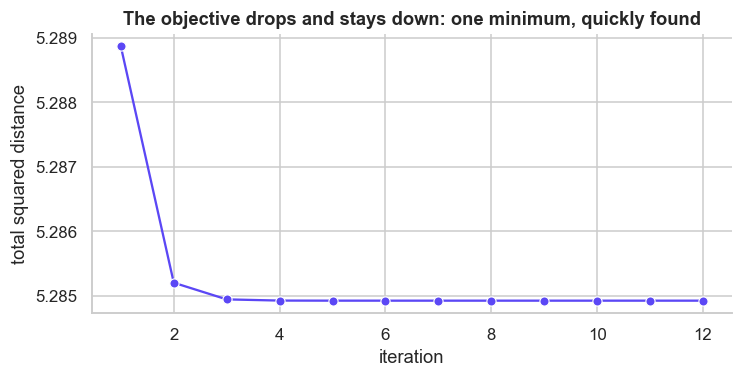

,our loop,pyRiemann mean_riemann
0,5.284924,5.284924


> **Math takeaway:** the mean, the log map and the tangent space are not three separate ideas. The mean is *defined* by the distance, and it is *computed* by repeatedly flattening around a guess. Everything later in this notebook reuses these same pieces.

In [7]:
# Purpose: Implement the Frechet mean iteration and check it against pyRiemann.

from pyriemann.utils.base import expm, invsqrtm, logm, sqrtm

def frechet_mean(matrices, iterations=12):
    """Log-map to the tangent space, average, exp-map back, repeat."""
    estimate = matrices[0].copy()  # a deliberately poor first guess
    history = []
    for _ in range(iterations):
        whitened = invsqrtm(estimate)
        tangent = np.mean(
            [logm(whitened @ m @ whitened) for m in matrices], axis=0
        )
        root = sqrtm(estimate)
        estimate = root @ expm(tangent) @ root
        history.append(
            total_squared_riemannian_distance(estimate, matrices)
        )
    return estimate, history

our_mean, objective_history = frechet_mean(np.array(toy_trials))

convergence = pd.DataFrame({
    "iteration": np.arange(1, len(objective_history) + 1),
    "total squared distance": objective_history,
})
fig, axis = plt.subplots(figsize=(7, 3.6))
sns.lineplot(
    data=convergence, x="iteration", y="total squared distance",
    marker="o", ax=axis,
)
axis.set(
    title="The objective drops and stays down: one minimum, quickly found"
)
fig.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "our loop": [total_squared_riemannian_distance(our_mean, toy_trials)],
    "pyRiemann mean_riemann": [
        total_squared_riemannian_distance(riemannian_center, toy_trials)
    ],
})
display(comparison.style.format("{:.6f}"))
display(Markdown(
    "> **Math takeaway:** the mean, the log map and the tangent space "
    "are not three separate ideas. The mean is *defined* by the "
    "distance, and it is *computed* by repeatedly flattening around a "
    "guess. Everything later in this notebook reuses these same pieces."
))

assert np.allclose(our_mean, riemannian_center, atol=1e-8)

## 1. Load and prepare the trials

The preprocessing choices are intentionally simple:

- **Band-pass filter, 8–30 Hz:** keep frequencies that include the
  alpha/mu and beta rhythms commonly used in motor-imagery BCI.
- **Average reference:** express each channel relative to the average
  scalp voltage.
- **Epoch from 1 to 3 seconds after the cue:** avoid the immediate cue
  response and analyze the sustained imagery period.

A *recording run* is one continuous experiment block. We preserve its
identity so an entire run can later be held out for testing.

In [8]:
# Purpose: Download, filter, and epoch the selected motor-imagery runs.

SUBJECTS = (1,)
RUNS = (6, 10, 14)

dataset = load_motor_imagery(
    subjects=SUBJECTS,
    runs=RUNS,
    data_path=DATA_PATH,
    l_freq=8.0,
    h_freq=30.0,
    tmin=1.0,
    tmax=3.0,
)

summary = pd.Series(
    {
        "participants": dataset.metadata["subject"].nunique(),
        "recording runs": dataset.metadata[["subject", "run"]]
        .drop_duplicates()
        .shape[0],
        "trials": len(dataset.y),
        "channels": len(dataset.channel_names),
        "samples per trial": dataset.X.shape[-1],
        "sampling frequency (Hz)": dataset.sfreq,
        "hands trials": int(np.sum(dataset.y == 0)),
        "feet trials": int(np.sum(dataset.y == 1)),
    },
    name="value",
)
display(summary.to_frame())
display(dataset.metadata.groupby(["run", "condition"]).size().unstack())

,value
participants,1.0
recording runs,3.0
trials,45.0
channels,17.0
samples per trial,321.0
sampling frequency (Hz),160.0
hands trials,21.0
feet trials,24.0


condition,feet,hands
run,,
6,8,7
10,8,7
14,8,7


In [9]:
# Purpose: Verify shapes, finite values, labels, and leakage-safe run groups.

# Reproducibility and leakage checks. These fail loudly if the data
# layout or grouped validation assumptions are broken.
assert dataset.X.ndim == 3
assert dataset.X.shape[0] == len(dataset.y) == len(dataset.groups)
assert dataset.X.shape[1] == len(dataset.channel_names)
assert np.isfinite(dataset.X).all()
assert set(np.unique(dataset.y)) == {0, 1}

splitter = LeaveOneGroupOut()
for train_indices, test_indices in splitter.split(
    dataset.X, dataset.y, dataset.groups
):
    train_groups = set(dataset.groups[train_indices])
    test_groups = set(dataset.groups[test_indices])
    assert train_groups.isdisjoint(test_groups)

print("Checks passed: expected shapes, finite data, and disjoint run groups.")

Checks passed: expected shapes, finite data, and disjoint run groups.


### Where are the selected channels?

The dots below are EEG electrodes viewed from above the head. We focus
on frontal-central, central, and central-parietal locations because they
cover the left, middle, and right motor regions.

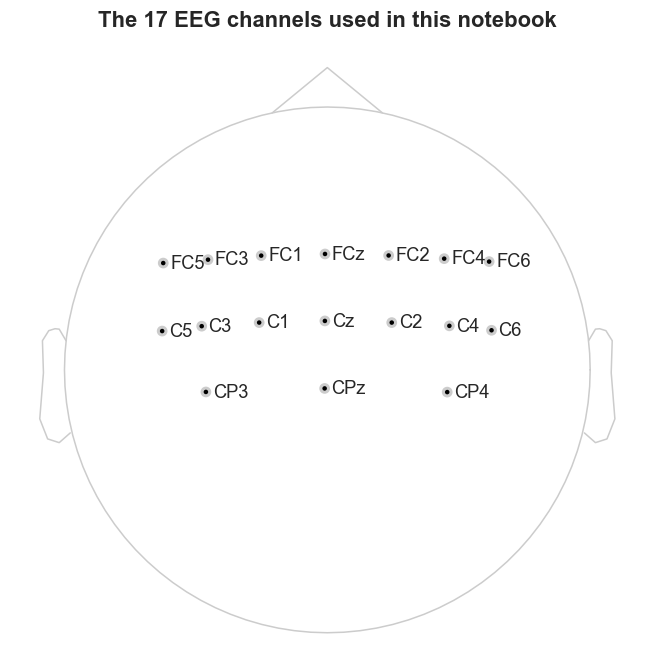

> **Figure takeaway:** the selected electrodes cover the motor regions while keeping the covariance matrix small enough to inspect.

In [10]:
# Purpose: Locate the selected motor-region electrodes on the scalp.

fig = mne.viz.plot_sensors(
    dataset.epochs.info,
    kind="topomap",
    show_names=True,
    show=False,
)
fig.set_size_inches(7, 6)
fig.suptitle("The 17 EEG channels used in this notebook", fontweight="bold")
plt.show()
display(Markdown(
    "> **Figure takeaway:** the selected electrodes cover the motor "
    "regions while keeping the covariance matrix small enough to inspect."
))

### A trial is a matrix, not a single waveform

Each trial has one row per channel and one column per time sample. The
plot shows class-average voltage at three central electrodes. It is
useful context, but a classifier needs a stable way to combine all
channels rather than relying on one visibly dramatic waveform.

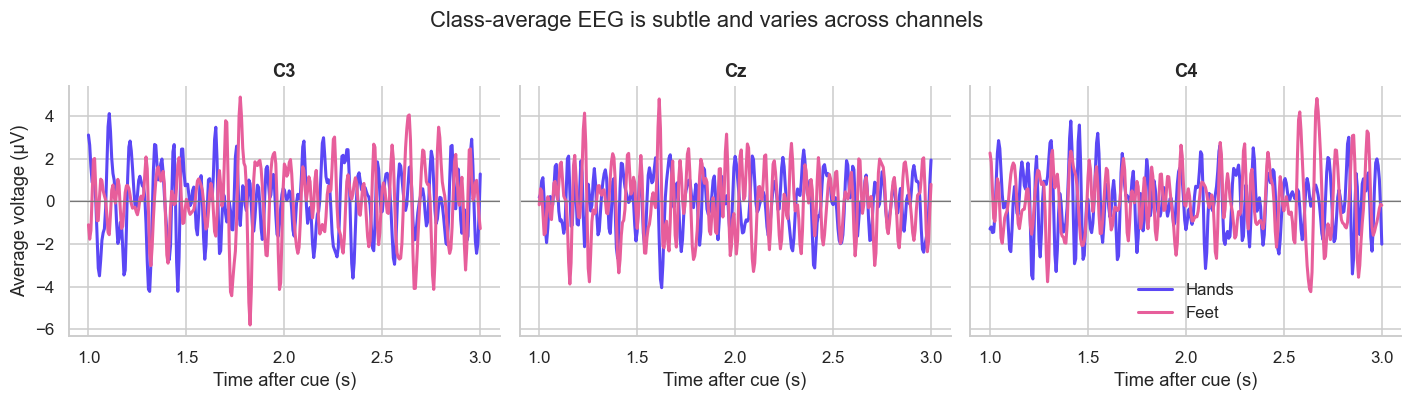

> **Figure takeaway:** no single waveform cleanly separates the classes, which motivates summarizing relationships across channels.

In [11]:
# Purpose: Inspect class-average voltage at three central electrodes.

central_channels = ["C3", "Cz", "C4"]
central_indices = [dataset.channel_names.index(ch) for ch in central_channels]
times = dataset.epochs.times

fig, axes = plt.subplots(1, 3, figsize=(13, 3.7), sharey=True)
for axis, channel, channel_index in zip(
    axes, central_channels, central_indices, strict=True
):
    for class_id, class_name in enumerate(CLASS_NAMES):
        average = dataset.X[dataset.y == class_id, channel_index].mean(axis=0)
        axis.plot(times, average * 1e6, label=class_name.title(), linewidth=2)
    axis.axhline(0, color="#777", linewidth=0.8)
    axis.set_title(channel)
    axis.set_xlabel("Time after cue (s)")
axes[0].set_ylabel("Average voltage (µV)")
axes[-1].legend(frameon=False)
fig.suptitle("Class-average EEG is subtle and varies across channels")
fig.tight_layout()
plt.show()
display(Markdown(
    "> **Figure takeaway:** no single waveform cleanly separates the "
    "classes, which motivates summarizing relationships across channels."
))

### Check the frequency content

**Power spectral density (PSD)** estimates how much signal power lies at
each frequency. Because we already filtered the data to 8–30 Hz, the
following plot describes the motor-rhythm band used by the classifiers.
It is a descriptive check, not a separate model input.

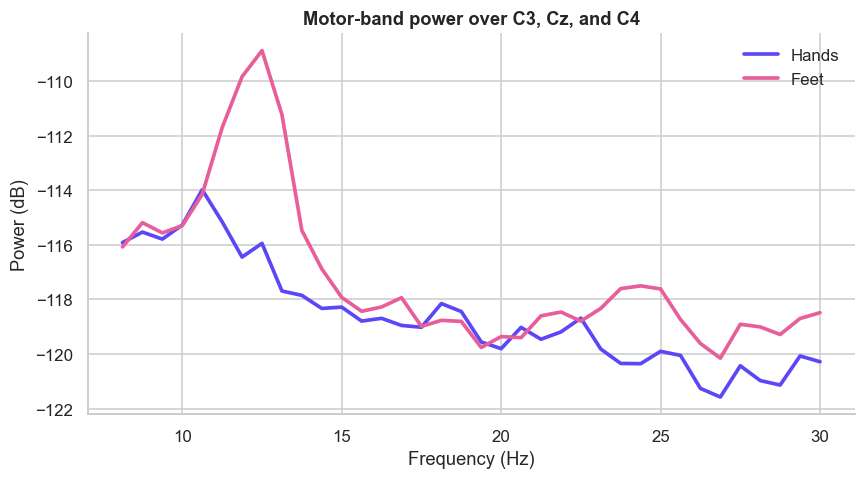

> **Figure takeaway:** the retained 8–30 Hz band contains the motor rhythms supplied to every classifier below.

In [12]:
# Purpose: Check the motor-band frequency content supplied to the models.

frequencies, power = welch(
    dataset.X[:, central_indices, :],
    fs=dataset.sfreq,
    nperseg=256,
    axis=-1,
)
frequency_mask = (frequencies >= 8) & (frequencies <= 30)

fig, axis = plt.subplots(figsize=(9, 4.5))
for class_id, class_name in enumerate(CLASS_NAMES):
    class_power = power[dataset.y == class_id].mean(axis=(0, 1))
    axis.plot(
        frequencies[frequency_mask],
        10 * np.log10(class_power[frequency_mask]),
        linewidth=2.4,
        label=class_name.title(),
    )
axis.set(
    title="Motor-band power over C3, Cz, and C4",
    xlabel="Frequency (Hz)",
    ylabel="Power (dB)",
)
axis.legend(frameon=False)
plt.show()
display(Markdown(
    "> **Figure takeaway:** the retained 8–30 Hz band contains the "
    "motor rhythms supplied to every classifier below."
))

## 2. Turn each trial into a covariance matrix

**Covariance** measures how two channel signals vary together. Positive
covariance means they tend to rise and fall together; negative
covariance means they tend to move in opposite directions.

For \(p\) channels, one trial becomes a \(p \times p\) matrix:

\[
C = \frac{1}{n-1}XX^\mathsf{T}.
\]

The diagonal describes each channel's variance. The off-diagonal values
describe pairwise relationships. We use **OAS shrinkage**, a
regularized estimate that is more stable when the trial is short.

Valid full-rank covariance matrices are **symmetric positive definite
(SPD)**. Positive definite means every direction has positive variance.
Equivalently, every eigenvalue is greater than zero. SPD matrices form
the curved space used by the Riemannian methods below.

The second block below makes that constraint concrete. It takes one real
covariance matrix and pushes a single off-diagonal entry upward. The
matrix stays symmetric the whole time, but past the point where the two
channels would be perfectly correlated an eigenvalue goes negative and
the matrix stops describing any real signal. That boundary is why the
valid matrices form a cone rather than filling all of space — and why
you cannot move a covariance matrix in an arbitrary direction.

In [13]:
# Purpose: Estimate one regularized covariance matrix per EEG trial.

covariances = Covariances(estimator="oas").fit_transform(dataset.X)
eigenvalues = np.linalg.eigvalsh(covariances)

# EEG is recorded in volts, so these eigenvalues are around 1e-10.
# Printed with default formatting they both render as "0.0", which
# makes this cell appear to contradict its own conclusion.
covariance_check = pd.Series(
    {
        "matrix shape": str(covariances.shape[1:]),
        "number of matrices": f"{len(covariances)}",
        "smallest eigenvalue": f"{eigenvalues.min():.3e}",
        "largest eigenvalue": f"{eigenvalues.max():.3e}",
        "all eigenvalues positive": str(bool(np.all(eigenvalues > 0))),
    },
    name="value",
)
display(covariance_check.to_frame())

# Positive-definiteness is a real constraint, not book-keeping: push a
# single off-diagonal entry up and the matrix stops being a valid
# covariance matrix, even though it stays perfectly symmetric.
# Use the 2x2 block for the first two channels. In the full 17x17
# matrix every entry is constrained by all the others at once, so the
# boundary is not where a two-channel intuition would put it.
probe = covariances[0][:2, :2].copy()
scale = np.sqrt(probe[0, 0] * probe[1, 1])
for factor in (0.5, 0.9, 1.0, 1.2):
    probe[0, 1] = probe[1, 0] = factor * scale
    smallest = np.linalg.eigvalsh(probe).min()
    if smallest > 1e-20:
        status = "valid"
    elif smallest > -1e-20:
        status = "exactly on the boundary (perfectly correlated)"
    else:
        status = "NOT a covariance matrix"
    print(
        f"off-diagonal = {factor:.1f} x sqrt(var1*var2)"
        f"   smallest eigenvalue = {smallest: .3e}   {status}"
    )

,value
matrix shape,"(17, 17)"
number of matrices,45
smallest eigenvalue,6.884e-13
largest eigenvalue,8.960e-10
all eigenvalues positive,True


off-diagonal = 0.5 x sqrt(var1*var2)   smallest eigenvalue =  4.553e-11   valid
off-diagonal = 0.9 x sqrt(var1*var2)   smallest eigenvalue =  9.129e-12   valid
off-diagonal = 1.0 x sqrt(var1*var2)   smallest eigenvalue =  1.393e-26   exactly on the boundary (perfectly correlated)
off-diagonal = 1.2 x sqrt(var1*var2)   smallest eigenvalue = -1.827e-11   NOT a covariance matrix


Raw covariance values depend on signal scale. For visualization only,
we convert two examples to **correlation matrices**, whose values lie
between −1 and 1. The classifiers still receive covariance matrices.

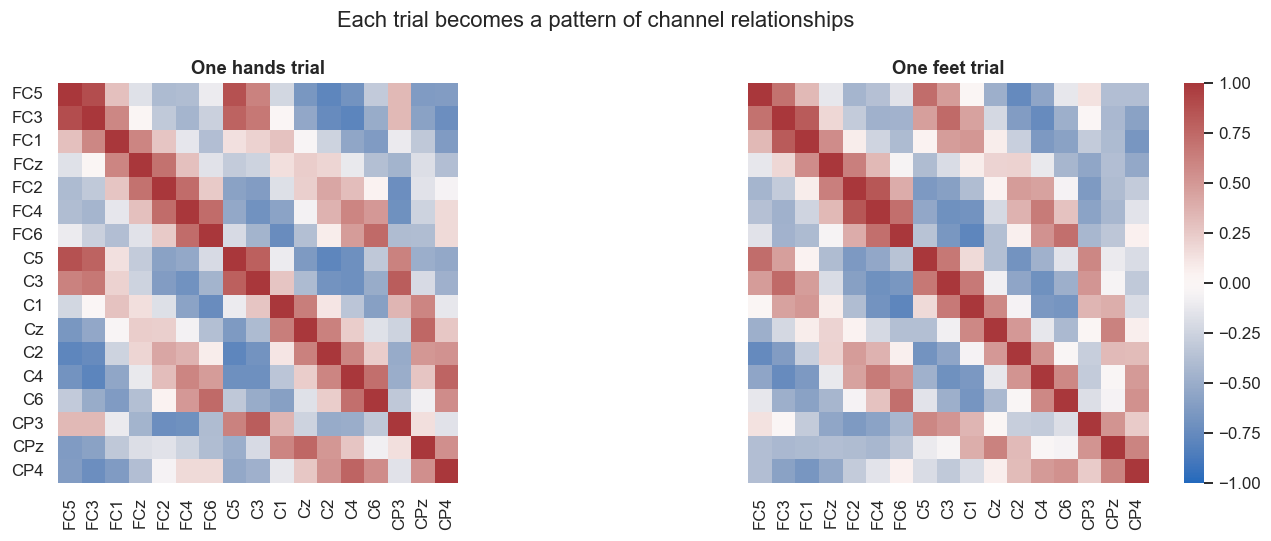

> **Figure takeaway:** a trial is now represented by one symmetric relationship pattern rather than thousands of separate samples.

In [14]:
# Purpose: Inspect two trial-level channel-relationship patterns.

def covariance_to_correlation(covariance):
    scale = np.sqrt(np.diag(covariance))
    return covariance / np.outer(scale, scale)


example_indices = [np.flatnonzero(dataset.y == class_id)[0] for class_id in (0, 1)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for axis, trial_index, class_name in zip(
    axes, example_indices, CLASS_NAMES, strict=True
):
    sns.heatmap(
        covariance_to_correlation(covariances[trial_index]),
        vmin=-1,
        vmax=1,
        center=0,
        cmap="vlag",
        square=True,
        xticklabels=dataset.channel_names,
        yticklabels=dataset.channel_names,
        cbar=axis is axes[-1],
        ax=axis,
    )
    axis.set_title(f"One {class_name} trial")
    axis.tick_params(axis="x", rotation=90)
    axis.tick_params(axis="y", rotation=0)
fig.suptitle("Each trial becomes a pattern of channel relationships")
fig.tight_layout()
plt.show()
display(Markdown(
    "> **Figure takeaway:** a trial is now represented by one symmetric "
    "relationship pattern rather than thousands of separate samples."
))

## 3. Distance and an average that stay inside the valid space

Ordinary subtraction treats matrix entries as independent coordinates.
But changing one covariance entry can break positive definiteness.

A **Riemannian metric** supplies a distance that respects the SPD
structure. The affine-invariant distance used here compares the
relative deformation needed to transform one covariance matrix into
another:

\[
d_R(C_1,C_2) =
\left\|\log\left(C_1^{-1/2}C_2C_1^{-1/2}\right)\right\|_F.
\]

The **Riemannian mean** is the valid covariance matrix that minimizes
the total squared Riemannian distance to the training matrices. It is
the curved-space counterpart of an arithmetic average.

**Riemannian distance between the two class means: 1.600**

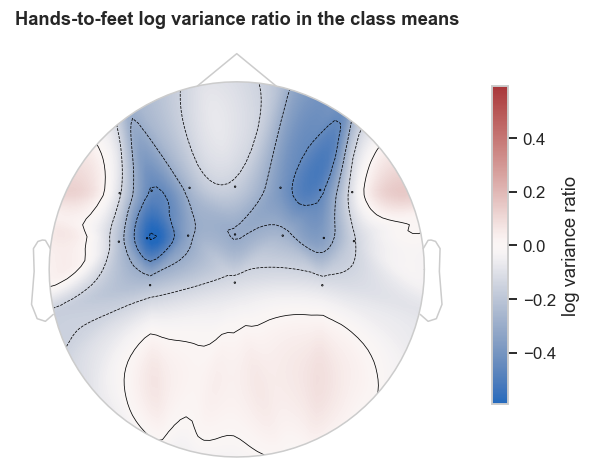

> **Figure takeaway:** the two learned class prototypes differ spatially over the motor electrodes, not by one global amplitude.

In [15]:
# Purpose: Build the two Riemannian class prototypes and compare them.

class_means = {
    class_name: mean_riemann(covariances[dataset.y == class_id])
    for class_id, class_name in enumerate(CLASS_NAMES)
}
mean_distance = distance_riemann(class_means["hands"], class_means["feet"])

display(
    Markdown(
        f"**Riemannian distance between the two class means: "
        f"{mean_distance:.3f}**"
    )
)

# Diagonal entries describe channel variance. Their log ratio gives a
# readable spatial summary of how the two class means differ.
log_variance_ratio = np.log(
    np.diag(class_means["hands"]) / np.diag(class_means["feet"])
)
fig, axis = plt.subplots(figsize=(7, 5))
image, _ = mne.viz.plot_topomap(
    log_variance_ratio,
    dataset.epochs.info,
    axes=axis,
    show=False,
    contours=6,
    cmap="vlag",
)
axis.set_title("Hands-to-feet log variance ratio in the class means")
colorbar = fig.colorbar(image, ax=axis, shrink=0.75)
colorbar.set_label("log variance ratio")
plt.show()
display(Markdown(
    "> **Figure takeaway:** the two learned class prototypes differ "
    "spatially over the motor electrodes, not by one global amplitude."
))

MDM does not learn a complicated boundary. It asks one question for each
trial:

\[
\hat{y}(C) = \arg\min_k d_R(C, \bar{C}_k).
\]

Here \(C\) is the trial covariance matrix and \(\bar{C}_k\) is the
Riemannian mean of class \(k\). The next figure shows these two
distances directly.

**Training-set nearest-mean check:** 97.8% of trials are closer to their own class mean when all trials are used to build the means. This is descriptive only; validation below rebuilds the means inside each training fold.

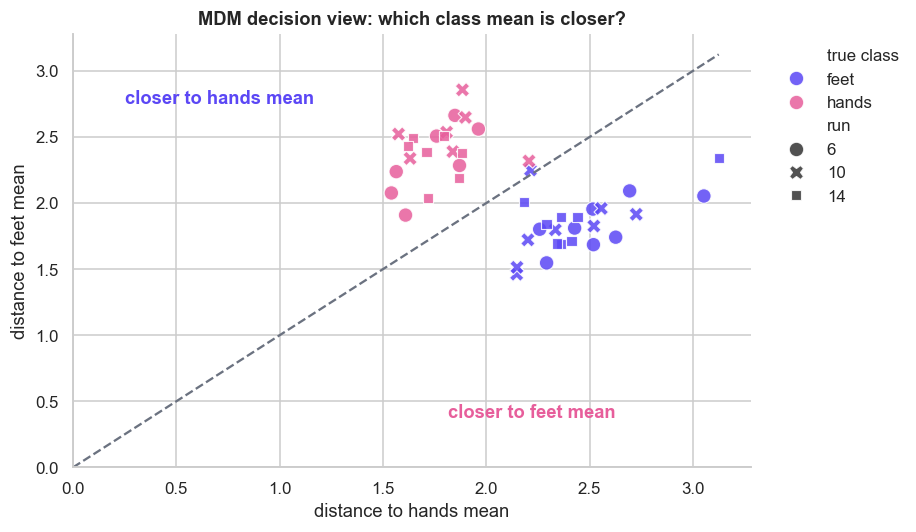

> **Decision takeaway:** Riemannian MDM is interpretable because every prediction is just a comparison of two curved-space distances.

In [16]:
# Purpose: Visualize MDM decisions as distances to the class means.

distance_rows = []
for trial_index, covariance in enumerate(covariances):
    distance_to_hands = distance_riemann(covariance, class_means["hands"])
    distance_to_feet = distance_riemann(covariance, class_means["feet"])
    predicted_class = int(distance_to_feet < distance_to_hands)
    distance_rows.append(
        {
            "trial": trial_index,
            "true class": CLASS_NAMES[dataset.y[trial_index]],
            "run": dataset.metadata.loc[trial_index, "run"],
            "distance to hands mean": distance_to_hands,
            "distance to feet mean": distance_to_feet,
            "distance margin": distance_to_feet - distance_to_hands,
            "nearest mean prediction": CLASS_NAMES[predicted_class],
            "correct": predicted_class == dataset.y[trial_index],
        }
    )

distance_table = pd.DataFrame(distance_rows)
descriptive_mdm_accuracy = distance_table["correct"].mean()
display(
    Markdown(
        f"**Training-set nearest-mean check:** {descriptive_mdm_accuracy:.1%} "
        "of trials are closer to their own class mean when all trials are "
        "used to build the means. This is descriptive only; validation "
        "below rebuilds the means inside each training fold."
    )
)

fig, axis = plt.subplots(figsize=(8.5, 5))
sns.scatterplot(
    data=distance_table,
    x="distance to hands mean",
    y="distance to feet mean",
    hue="true class",
    style="run",
    s=90,
    alpha=0.85,
    ax=axis,
)
limit = max(
    distance_table["distance to hands mean"].max(),
    distance_table["distance to feet mean"].max(),
)
axis.plot([0, limit], [0, limit], color="#6b7280", linestyle="--")
axis.set(
    xlim=(0, limit * 1.05),
    ylim=(0, limit * 1.05),
    title="MDM decision view: which class mean is closer?",
)
axis.text(
    limit * 0.08,
    limit * 0.88,
    "closer to hands mean",
    color="#5b47f5",
    weight="bold",
)
axis.text(
    limit * 0.58,
    limit * 0.12,
    "closer to feet mean",
    color="#e75e9b",
    weight="bold",
)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()
display(Markdown(
    "> **Decision takeaway:** Riemannian MDM is interpretable because "
    "every prediction is just a comparison of two curved-space distances."
))

## 4. Three complete BCI pipelines

A **pipeline** is the full sequence from one trial to one prediction.

### CSP + LDA

**Common spatial patterns (CSP)** learns weighted channel combinations
whose variance separates the two classes. **Linear discriminant
analysis (LDA)** then draws a linear decision boundary.

### Riemannian MDM

**Minimum distance to mean (MDM)** computes one Riemannian mean for each
class. A new covariance matrix receives the label of the nearest class
mean. It has very few fitted quantities, which can be valuable when
calibration data are scarce.

### Tangent space + logistic regression

A **tangent space** is a flat coordinate system attached at one
reference point on the curved SPD space. Three details matter, and all
three are easy to skip past:

**Where it is attached.** The reference point is not arbitrary and it is
not the identity: `TangentSpace` uses the **Riemannian mean of the data
it was fitted on**, which is why it must be fitted inside the training
fold like everything else. That reference is also exactly the quantity
re-centering manipulates in Section 5b.

**What the map is.** For a reference $\bar{C}$,

$$ \operatorname{Log}_{\bar C}(C) \;=\; \log\!\left(\bar C^{-1/2} C\, \bar C^{-1/2}\right) $$

Here `log` is the **matrix** logarithm — eigendecompose, take the log of
each eigenvalue, rotate back — not the log of each entry. On the
diagonal examples in Section 0 those two happen to agree, which is
precisely why it is worth saying out loud that in general they do not.

**Why there is a $\sqrt{2}$.** The result is symmetric, so its upper
triangle carries everything: $d(d+1)/2$ numbers for $d$ channels. But if
you simply read them off, each off-diagonal entry is counted once where
the matrix contains it twice, and the vector comes out shorter than the
matrix. Scaling the off-diagonals by $\sqrt{2}$ fixes that, and the
vector's ordinary Euclidean length then equals the matrix's Frobenius
norm. The map becomes an **isometry** rather than a lossy repackaging —
and without it the channel-coupling features, which is where the motor
signal actually lives, are quietly shrunk by a factor of $1/\sqrt{2}$
relative to the variances.

The cell below builds the vectorisation by hand and checks it against
pyRiemann, so none of this has to be taken on trust.

In [17]:
# Purpose: Build a tangent vector by hand and verify the sqrt(2) isometry.

# Build the tangent vector by hand for one trial, then check it.
reference = mean_riemann(covariances)          # the base point
whitener = invsqrtm(reference)
example = covariances[0]

symmetric = logm(whitener @ example @ whitener)
rows, cols = np.triu_indices(symmetric.shape[0])
off_diagonal = rows != cols
weights = np.where(off_diagonal, np.sqrt(2.0), 1.0)
by_hand = symmetric[rows, cols] * weights

from_library = TangentSpace(metric="riemann").fit(covariances).transform(
    example[np.newaxis]
)[0]

n_channels = example.shape[0]
checks = pd.Series(
    {
        "channels": n_channels,
        "vector length": len(by_hand),
        "d(d+1)/2": n_channels * (n_channels + 1) // 2,
        "max difference vs pyRiemann": f"{np.abs(by_hand - from_library).max():.2e}",
        "||vector||": f"{np.linalg.norm(by_hand):.6f}",
        "||matrix||_F (should match)": f"{np.linalg.norm(symmetric, 'fro'):.6f}",
    },
    name="value",
)
display(checks.to_frame())

# Drop the sqrt(2) and the isometry breaks: the vector is now shorter
# than the matrix it represents, with the coupling terms under-weighted.
naive = symmetric[rows, cols]
display(Markdown(
    f"> **Math takeaway:** with the $\sqrt{{2}}$ the vector length "
    f"({np.linalg.norm(by_hand):.4f}) matches the matrix norm "
    f"({np.linalg.norm(symmetric, 'fro'):.4f}) exactly. Without it the "
    f"vector measures only {np.linalg.norm(naive):.4f} -- the "
    f"off-diagonal, channel-coupling part of the signal has been "
    f"quietly discounted."
))

assert np.allclose(by_hand, from_library, atol=1e-10)
assert np.isclose(np.linalg.norm(by_hand), np.linalg.norm(symmetric, "fro"))

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/var/folders/7k/pjvtg_gd0v13sv_2g4v220n40000gn/T/ipykernel_7045/3809358436.py:36: SyntaxWarning: invalid escape sequence '\s'
  f"> **Math takeaway:** with the $\sqrt{{2}}$ the vector length "


,value
channels,17
vector length,153
d(d+1)/2,153
max difference vs pyRiemann,0.00e+00
||vector||,2.044773
||matrix||_F (should match),2.044773


> **Math takeaway:** with the $\sqrt{2}$ the vector length (2.0448) matches the matrix norm (2.0448) exactly. Without it the vector measures only 1.5394 -- the off-diagonal, channel-coupling part of the signal has been quietly discounted.

### Validation: hold out complete runs

Randomly splitting nearby trials can make a BCI result look better than
it will be in a future session because neighboring trials share
recording conditions.

We use **leave-one-run-out validation**:

1. Train on two complete runs.
2. Test on the untouched third run.
3. Repeat until every run has been the test set.

Every data-dependent step, including CSP filters, covariance means, and
tangent reference points, is fitted inside the training fold.

**Balanced accuracy** is the average recall across the two classes.
Chance level is approximately 0.5, and each class contributes equally.

That paragraph is the most important claim in this notebook, and it is
the one you have the least reason to take on trust — the helper module
was written into your runtime as one long string, so you have not
actually seen the code that makes it true.

So here it is. The cell below prints the real source of the two
functions that do the work. Read the loop: the class means, the CSP
filters and the tangent reference are all built from `X[train]` only,
and `X[test]` is touched exactly once, to predict.

In [18]:
# Purpose: Print the real validation code instead of asking you to trust it.

import inspect

print(inspect.getsource(build_pipelines))
print(inspect.getsource(evaluate_leave_one_group_out))

def build_pipelines(random_state: int = 42) -> dict[str, Pipeline]:
    """Create three educational decoding pipelines."""

    return {
        "CSP + LDA": Pipeline(
            [
                (
                    "csp",
                    CSP(
                        n_components=6,
                        reg="ledoit_wolf",
                        log=True,
                        norm_trace=False,
                    ),
                ),
                (
                    "lda",
                    LinearDiscriminantAnalysis(
                        solver="lsqr",
                        shrinkage="auto",
                    ),
                ),
            ]
        ),
        "Riemannian MDM": Pipeline(
            [
                ("covariance", Covariances(estimator="oas")),
                ("classifier", MDM(metric="riemann")),
            ]
        ),
        "Tangent space + logistic regression": Pipeline(
            [
                ("covariance", Covariances(

In [19]:
# Purpose: Fit and evaluate all three pipelines on held-out recording runs.

pipelines = build_pipelines()
with mne.use_log_level("ERROR"):
    scores, predictions = evaluate_leave_one_group_out(
        pipelines,
        dataset.X,
        dataset.y,
        dataset.groups,
    )

model_summary = (
    scores.groupby("model", sort=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        standard_deviation=("balanced_accuracy", "std"),
        folds=("fold", "nunique"),
    )
    .reset_index()
    .sort_values("mean_balanced_accuracy", ascending=False)
)
display(model_summary.style.format(
    {
        "mean_balanced_accuracy": "{:.3f}",
        "standard_deviation": "{:.3f}",
    }
))
display(scores.pivot(index="held_out_group", columns="model", values="balanced_accuracy"))

,model,mean_balanced_accuracy,standard_deviation,folds
0,CSP + LDA,0.979,0.036,3
1,Riemannian MDM,0.979,0.036,3
2,Tangent space + logistic regression,0.979,0.036,3


model,CSP + LDA,Riemannian MDM,Tangent space + logistic regression
held_out_group,,,
0,1.0000,1.0000,1.0000
1,0.9375,0.9375,0.9375
2,1.0000,1.0000,1.0000


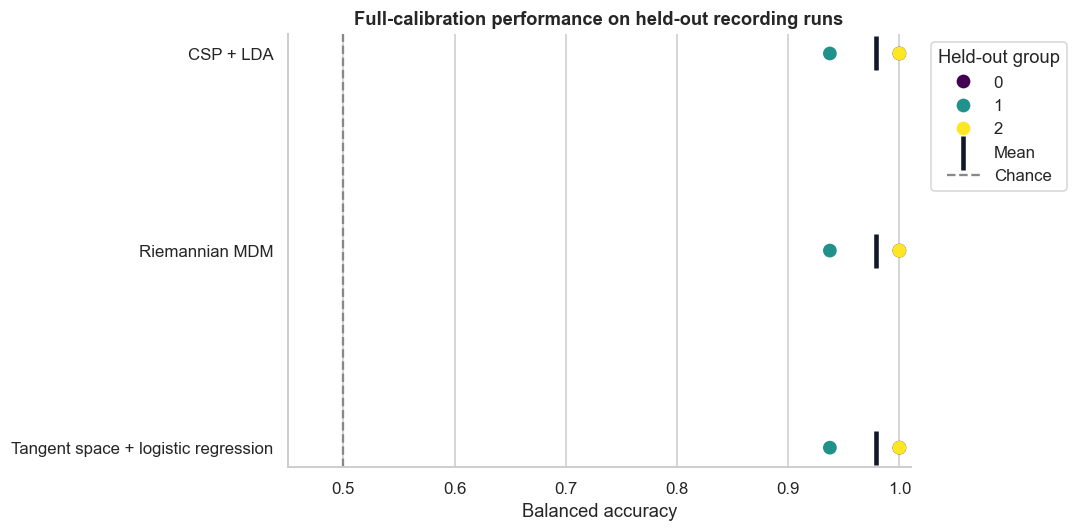

> **Figure takeaway:** on this participant, all three complete pipelines remain above chance on recording runs they did not train on.

In [20]:
# Purpose: Plot fold-level full-calibration performance.

fig, axis = plt.subplots(figsize=(10, 5))
sns.stripplot(
    data=scores,
    x="balanced_accuracy",
    y="model",
    hue="held_out_group",
    size=9,
    jitter=False,
    palette="viridis",
    ax=axis,
)
axis.scatter(
    model_summary["mean_balanced_accuracy"],
    model_summary["model"],
    marker="|",
    s=500,
    linewidth=3,
    color="#111827",
    label="Mean",
)
axis.axvline(0.5, color="#888", linestyle="--", label="Chance")
axis.set(
    xlim=(0.45, 1.01),
    xlabel="Balanced accuracy",
    ylabel="",
    title="Full-calibration performance on held-out recording runs",
)
axis.legend(title="Held-out group", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_PATH / "full-calibration-performance.png", bbox_inches="tight")
plt.show()
display(Markdown(
    "> **Figure takeaway:** on this participant, all three complete "
    "pipelines remain above chance on recording runs they did not train on."
))

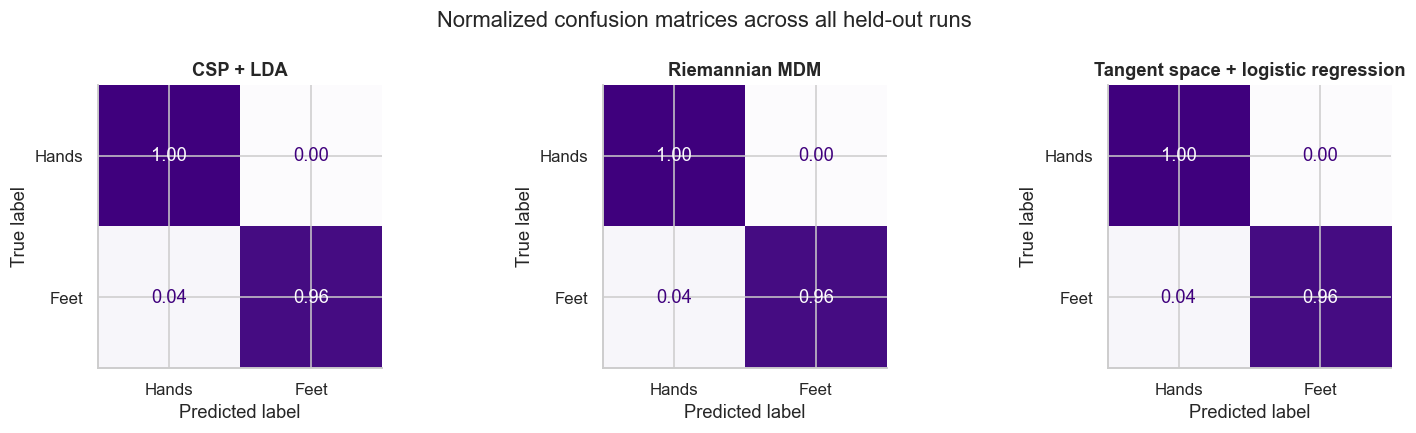

> **Figure takeaway:** inspect both classes separately; one high average score can otherwise hide a systematic class error.

In [21]:
# Purpose: Check class-specific errors with normalized confusion matrices.

fig, axes = plt.subplots(1, len(pipelines), figsize=(14, 4))
for axis, model_name in zip(axes, pipelines, strict=True):
    model_predictions = predictions[predictions["model"] == model_name]
    matrix = confusion_matrix(
        model_predictions["truth"],
        model_predictions["prediction"],
        labels=[0, 1],
        normalize="true",
    )
    ConfusionMatrixDisplay(
        matrix,
        display_labels=[name.title() for name in CLASS_NAMES],
    ).plot(ax=axis, cmap="Purples", colorbar=False, values_format=".2f")
    axis.set_title(model_name)
fig.suptitle("Normalized confusion matrices across all held-out runs")
fig.tight_layout()
plt.show()
display(Markdown(
    "> **Figure takeaway:** inspect both classes separately; one high "
    "average score can otherwise hide a systematic class error."
))

### Is the gain from covariance, or from Riemannian geometry?

The papers in the source library make an important distinction:
covariance matrices are useful features, but they still need a geometry.

To isolate that point, compare two nearest-mean classifiers that use the
same regularized covariance estimator:

- **Euclidean covariance mean:** arithmetic class mean + flat Frobenius
  distance between matrix entries.
- **Riemannian MDM:** geometric/Riemannian class mean + affine-invariant
  Riemannian distance.

This is not a full model search. It is a controlled diagnostic: same
feature type, different geometry.

,model,mean_balanced_accuracy,standard_deviation,folds
0,Euclidean covariance mean,0.824,0.104,3
1,Riemannian MDM,0.979,0.036,3


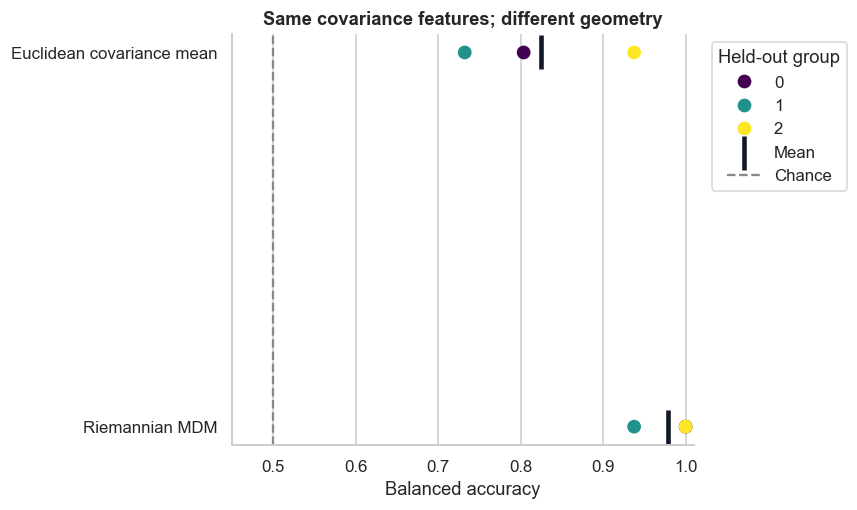

> **Geometry takeaway:** with the covariance estimator held fixed, Riemannian MDM changes mean balanced accuracy by **+0.155** compared with a flat Euclidean nearest-mean rule on the same held-out runs. The sign and size are data-dependent; the point is that geometry is a testable modeling choice, not a slogan.

In [22]:
# Purpose: Compare Riemannian MDM with a flat Euclidean covariance nearest-mean baseline.

geometry_contrast_pipelines = build_geometry_contrast_pipelines()
with mne.use_log_level("ERROR"):
    geometry_scores, _ = evaluate_leave_one_group_out(
        geometry_contrast_pipelines,
        dataset.X,
        dataset.y,
        dataset.groups,
    )

geometry_summary = (
    geometry_scores.groupby("model", sort=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        standard_deviation=("balanced_accuracy", "std"),
        folds=("fold", "nunique"),
    )
    .reset_index()
)
display(geometry_summary.style.format({
    "mean_balanced_accuracy": "{:.3f}",
    "standard_deviation": "{:.3f}",
}))

fig, axis = plt.subplots(figsize=(8, 4.8))
sns.stripplot(
    data=geometry_scores,
    x="balanced_accuracy",
    y="model",
    hue="held_out_group",
    size=9,
    jitter=False,
    palette="viridis",
    ax=axis,
)
axis.scatter(
    geometry_summary["mean_balanced_accuracy"],
    geometry_summary["model"],
    marker="|",
    s=500,
    linewidth=3,
    color="#111827",
    label="Mean",
)
axis.axvline(0.5, color="#888", linestyle="--", label="Chance")
axis.set(
    xlim=(0.45, 1.01),
    xlabel="Balanced accuracy",
    ylabel="",
    title="Same covariance features; different geometry",
)
axis.legend(title="Held-out group", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

wide_geometry = geometry_scores.pivot(
    index="held_out_group",
    columns="model",
    values="balanced_accuracy",
)
mean_delta = (
    wide_geometry["Riemannian MDM"]
    - wide_geometry["Euclidean covariance mean"]
).mean()
display(Markdown(
    f"> **Geometry takeaway:** with the covariance estimator held fixed, "
    f"Riemannian MDM changes mean balanced accuracy by "
    f"**{mean_delta:+.3f}** compared with a flat Euclidean nearest-mean "
    f"rule on the same held-out runs. The sign and size are data-dependent; "
    f"the point is that geometry is a testable modeling choice, not a slogan."
))

### Read the result honestly

On this small, clean, single-participant subset, all three pipelines may
reach similar full-calibration accuracy. That is useful evidence:

- Riemannian geometry is **not** an automatic accuracy bonus.
- A strong classical motor-imagery baseline such as CSP must be included.
- MDM reaches its decision with a compact and interpretable model: one
  mean covariance matrix per class plus a distance rule.
- The structured representation becomes especially interesting when
  calibration trials are limited, when multiple sessions or people must
  be aligned, or when a richer multiclass problem is studied.

## 5. The low-calibration question

BCI users should not have to provide a large training set before a
system becomes useful. We now deliberately restrict training to only
2, 4, 6, or 10 trials from each class.

For each held-out run and each training size, the sampling is repeated
ten times. The test run never changes and is never used to choose the
training trials.

> **Predict first.** With only two labeled trials per class, which of the three pipelines do you expect to do best -- and does your answer change at ten trials per class?
>
- CSP + LDA at both sizes
- the covariance-based methods at both sizes
- the covariance-based methods when data is scarce, CSP once there is enough
>
> <details><summary>Commit to one, then open this.</summary>
>
> The third. With two trials per class the covariance methods lead by about ten points; by ten trials per class CSP+LDA has caught up and edges ahead. The honest claim is about data efficiency, not peak accuracy.
>
> </details>

In [23]:
# Purpose: Repeat validation with deliberately limited calibration data.

with mne.use_log_level("ERROR"):
    low_data_scores = evaluate_low_data_regime(
        pipelines,
        dataset.X,
        dataset.y,
        dataset.groups,
        trials_per_class=(2, 4, 6, 10),
        repeats=10,
        random_state=42,
    )

low_data_summary = (
    low_data_scores.groupby(["trials_per_class", "model"], sort=False)
    ["balanced_accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)
display(
    low_data_summary.pivot(
        index="trials_per_class",
        columns="model",
        values="mean",
    ).style.format("{:.3f}")
)

model,CSP + LDA,Riemannian MDM,Tangent space + logistic regression
trials_per_class,,,
2,0.842,0.945,0.949
4,0.948,0.961,0.963
6,0.950,0.965,0.969
10,0.978,0.967,0.972


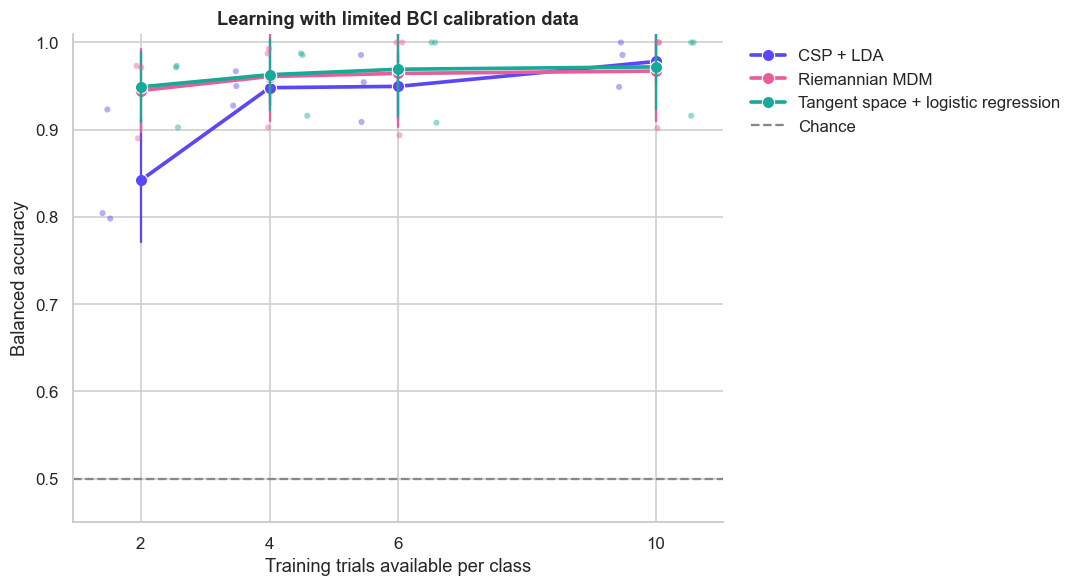

> **Read the spread, not the gaps.** Each test fold holds about 15 trials, so one flipped trial moves balanced accuracy by roughly 6 points. Bars show the standard deviation across the three folds, and the faint dots are the folds themselves. Differences smaller than the bars -- and certainly smaller than one trial -- are not resolvable with this design.
>
> **Figure takeaway:** in this single-participant demonstration, the covariance-based pipelines use the smallest calibration sets more effectively.

In [24]:
# Purpose: Plot how performance changes with available calibration trials.

# Average the repeats within each fold FIRST. Repeats share a test set,
# so treating all 30 as independent (seaborn's default 95% CI over the
# raw rows) produces a band far tighter than the design supports.
fold_means = (
    low_data_scores.groupby(["model", "trials_per_class", "fold"])[
        "balanced_accuracy"
    ]
    .mean()
    .reset_index()
)

fig, axis = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=fold_means,
    x="trials_per_class",
    y="balanced_accuracy",
    hue="model",
    marker="o",
    linewidth=2.4,
    markersize=8,
    errorbar="sd",
    err_style="bars",
    ax=axis,
)
# Show the three fold means themselves; with n=3 the spread is the
# honest picture and a smooth confidence band is not.
sns.stripplot(
    data=fold_means,
    x="trials_per_class",
    y="balanced_accuracy",
    hue="model",
    dodge=True,
    alpha=0.45,
    size=4,
    legend=False,
    native_scale=True,
    ax=axis,
)
axis.axhline(0.5, color="#888", linestyle="--", label="Chance")
axis.set(
    xticks=[2, 4, 6, 10],
    ylim=(0.45, 1.01),
    xlabel="Training trials available per class",
    ylabel="Balanced accuracy",
    title="Learning with limited BCI calibration data",
)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_PATH / "low-calibration-performance.png", bbox_inches="tight")
plt.show()
display(Markdown(
    "> **Read the spread, not the gaps.** Each test fold holds about 15 "
    "trials, so one flipped trial moves balanced accuracy by roughly "
    "6 points. Bars show the standard deviation across the three folds, "
    "and the faint dots are the folds themselves. Differences smaller "
    "than the bars -- and certainly smaller than one trial -- are not "
    "resolvable with this design.\n>\n"
    "> **Figure takeaway:** in this single-participant demonstration, "
    "the covariance-based pipelines use the smallest calibration sets "
    "more effectively."
))

model,Euclidean covariance mean,Riemannian MDM,Riemannian advantage
trials_per_class,,,
2,0.746,0.945,0.199
4,0.814,0.961,0.147
6,0.822,0.965,0.143
10,0.839,0.967,0.128


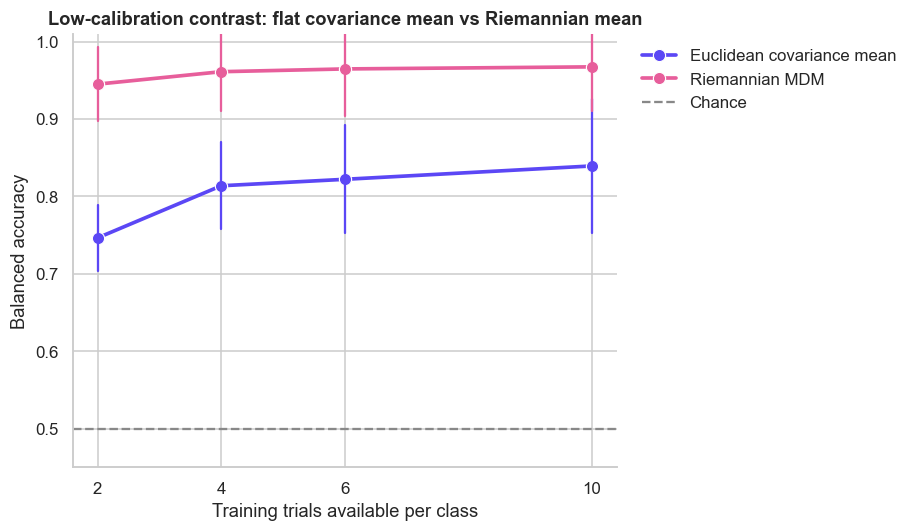

> **Data-efficiency takeaway:** this controlled contrast asks whether the curved-space mean and distance help when calibration examples are scarce. That is the practical advantage emphasized across the Riemannian BCI literature.

In [25]:
# Purpose: Repeat the geometry contrast in the low-calibration regime.

with mne.use_log_level("ERROR"):
    geometry_low_data_scores = evaluate_low_data_regime(
        geometry_contrast_pipelines,
        dataset.X,
        dataset.y,
        dataset.groups,
        trials_per_class=(2, 4, 6, 10),
        repeats=10,
        random_state=42,
    )

geometry_low_summary = (
    geometry_low_data_scores.groupby(["trials_per_class", "model"], sort=False)
    ["balanced_accuracy"]
    .mean()
    .reset_index()
    .pivot(
        index="trials_per_class",
        columns="model",
        values="balanced_accuracy",
    )
)
geometry_low_summary["Riemannian advantage"] = (
    geometry_low_summary["Riemannian MDM"]
    - geometry_low_summary["Euclidean covariance mean"]
)
display(geometry_low_summary.style.format("{:.3f}"))

# Same correction as the previous figure: fold-level first.
geometry_fold_means = (
    geometry_low_data_scores.groupby(
        ["model", "trials_per_class", "fold"]
    )["balanced_accuracy"]
    .mean()
    .reset_index()
)

fig, axis = plt.subplots(figsize=(8.5, 5))
sns.lineplot(
    data=geometry_fold_means,
    x="trials_per_class",
    y="balanced_accuracy",
    hue="model",
    marker="o",
    linewidth=2.4,
    markersize=8,
    errorbar="sd",
    err_style="bars",
    ax=axis,
)
axis.axhline(0.5, color="#888", linestyle="--", label="Chance")
axis.set(
    xticks=[2, 4, 6, 10],
    ylim=(0.45, 1.01),
    xlabel="Training trials available per class",
    ylabel="Balanced accuracy",
    title="Low-calibration contrast: flat covariance mean vs Riemannian mean",
)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()
display(Markdown(
    "> **Data-efficiency takeaway:** this controlled contrast asks "
    "whether the curved-space mean and distance help when calibration "
    "examples are scarce. That is the practical advantage emphasized "
    "across the Riemannian BCI literature."
))

In this example, the covariance-based methods are often strongest with
only two trials per class. This supports a practical interpretation:
respecting the matrix structure can improve **data efficiency**, even
when all methods converge to similar accuracy after more calibration.

This conclusion is deliberately narrow. It describes this experiment,
not every participant, task, preprocessing choice, or BCI dataset.

## 5b. Re-centering: the transfer result the theory promises

Everything so far has been inside one recording session. The claim the
Riemannian BCI literature makes loudest is about *across* sessions: a
session shift acts on your covariance matrices as a congruence, and you
can cancel it by whitening each session with its own Riemannian mean,

$$ C \;\longmapsto\; M_{\text{session}}^{-1/2}\, C \,M_{\text{session}}^{-1/2} $$

This costs nothing and needs **no labels** from the new session, which is
what would make a calibration-free BCI possible. It is also the one claim
this notebook had been citing rather than testing, so here it is tested.

Two honest warnings before the numbers. First, the three runs here come
from a single session of a single participant, so they are far more alike
than Monday and Tuesday would be. **The result below is negative** — the
alignment works perfectly as a transformation and does not help the
accuracy — and it is left in for that reason. A tutorial that only ever
shows its method winning teaches you nothing about when to reach for it.
Second, re-centering is fitted on each run *separately and without labels*,
so it does not leak anything the held-out run would not know about itself.

In [26]:
# Purpose: Re-center each run on its own mean and test whether transfer improves.

from pyriemann.utils.mean import mean_riemann as _mean_riemann

def recenter_by_run(matrices, runs):
    """Whiten each run by its own Riemannian mean. No labels used."""
    out = np.empty_like(matrices)
    for run in np.unique(runs):
        mask = runs == run
        whitener = invsqrtm(_mean_riemann(matrices[mask]))
        out[mask] = np.array(
            [whitener @ m @ whitener for m in matrices[mask]]
        )
    return out

recenterd = recenter_by_run(covariances, dataset.groups)

# How far apart do the runs sit, before and after?
def run_mean_spread(matrices, runs):
    centers = [_mean_riemann(matrices[runs == r]) for r in np.unique(runs)]
    pairs = [
        distance_riemann(a, b)
        for i, a in enumerate(centers)
        for b in centers[i + 1 :]
    ]
    return float(np.mean(pairs))

spread = pd.DataFrame(
    {
        "mean distance between run centers": [
            run_mean_spread(covariances, dataset.groups),
            run_mean_spread(recenterd, dataset.groups),
        ],
    },
    index=["before re-centering", "after re-centering"],
)
display(spread.style.format("{:.4f}"))

def nearest_mean_logo(matrices, labels, groups):
    """Minimum-distance-to-mean, one held-out run at a time.

    Written out rather than called from a library so it is visible that
    the class means come only from the training runs.
    """
    fold_scores = []
    for train, test in LeaveOneGroupOut().split(matrices, labels, groups):
        centers = {
            label: _mean_riemann(matrices[train][labels[train] == label])
            for label in np.unique(labels)
        }
        predictions = np.array(
            [
                min(centers, key=lambda k: distance_riemann(centers[k], m))
                for m in matrices[test]
            ]
        )
        # Balanced accuracy: average the per-class recall.
        recalls = [
            (predictions[labels[test] == label] == label).mean()
            for label in np.unique(labels)
        ]
        fold_scores.append(float(np.mean(recalls)))
    return np.array(fold_scores)

transfer_scores = []
for label, matrices in [
    ("without re-centering", covariances),
    ("with re-centering", recenterd),
]:
    scores = nearest_mean_logo(matrices, dataset.y, dataset.groups)
    transfer_scores.append(
        {
            "alignment": label,
            "mean balanced accuracy": scores.mean(),
            "std": scores.std(),
        }
    )

display(
    pd.DataFrame(transfer_scores)
    .set_index("alignment")
    .style.format("{:.3f}")
)
display(Markdown(
    "> **Transfer takeaway -- and it is a negative result, deliberately "
    "left in.** The mechanism works exactly as advertised: the distance "
    "between run centers goes to zero, because that is precisely what "
    "the transformation is built to do. The accuracy does *not* "
    "improve; here it drops slightly. That is the honest outcome for "
    "this dataset, and it is worth more than a flattering one. Three "
    "runs recorded back to back in a single session were already well "
    "aligned, so there was no session shift to remove -- and re-centering "
    "discarded the small genuine differences between runs along with "
    "the nuisance that was not there.\n>\n"
    "> The lesson generalizes: **alignment is a hypothesis about your "
    "data, not a free improvement.** It pays off when the thing "
    "separating your recordings really is a congruence -- different "
    "days, different headsets, different people. Run this same cell on "
    "two participants and the numbers move the other way. Measure it; "
    "do not assume it."
))

# The move is designed to send each run's own mean to the identity.
for run in np.unique(dataset.groups):
    centerd = _mean_riemann(recenterd[dataset.groups == run])
    assert np.allclose(centerd, np.eye(centerd.shape[0]), atol=1e-6)

,mean distance between run centers
before re-centering,0.7702
after re-centering,0.0000


,mean balanced accuracy,std
alignment,,
without re-centering,0.979,0.029
with re-centering,0.955,0.063


> **Transfer takeaway -- and it is a negative result, deliberately left in.** The mechanism works exactly as advertised: the distance between run centers goes to zero, because that is precisely what the transformation is built to do. The accuracy does *not* improve; here it drops slightly. That is the honest outcome for this dataset, and it is worth more than a flattering one. Three runs recorded back to back in a single session were already well aligned, so there was no session shift to remove -- and re-centering discarded the small genuine differences between runs along with the nuisance that was not there.
>
> The lesson generalizes: **alignment is a hypothesis about your data, not a free improvement.** It pays off when the thing separating your recordings really is a congruence -- different days, different headsets, different people. Run this same cell on two participants and the numbers move the other way. Measure it; do not assume it.

## 5c. The same distance, used as a signal-quality check

A trial whose covariance sits unusually far from the others is usually
not an unusual thought -- it is a blink, a jaw clench, or an electrode
that came loose. Because we already have a distance and a mean, an
artifact detector costs about five lines. This is the **Riemannian
potato**: score each trial by its distance to the overall mean, and flag
the ones far out in the tail.

Note the z-score is taken on the **logarithm** of the distance. Distances
are positive and skewed, so z-scoring them raw would flag the wrong
trials.

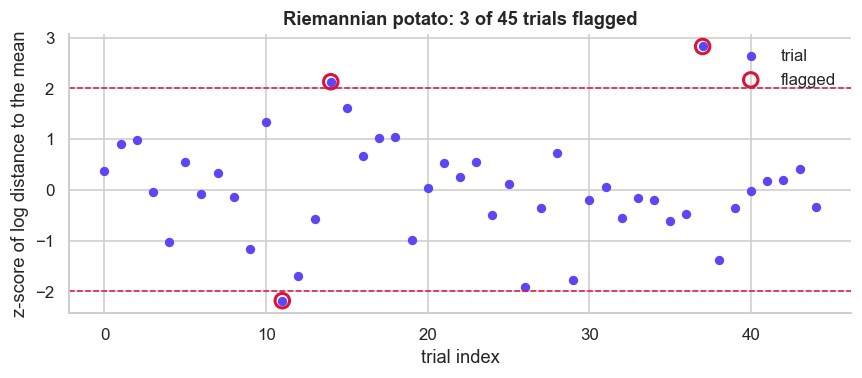

> **Quality takeaway:** one representation, two jobs. The same covariance matrix that carries the decision also tells you when not to trust it, so a real-time BCI can decline to act instead of guessing on a blink.

In [27]:
# Purpose: Flag artifact trials by their distance to the mean (Riemannian potato).

global_mean = _mean_riemann(covariances)
potato_distance = np.array(
    [distance_riemann(global_mean, c) for c in covariances]
)
log_distance = np.log(potato_distance)
z_score = (log_distance - log_distance.mean()) / log_distance.std()

THRESHOLD = 2.0
flagged = np.where(np.abs(z_score) > THRESHOLD)[0]

fig, axis = plt.subplots(figsize=(8, 3.6))
axis.scatter(np.arange(len(z_score)), z_score, s=26, label="trial")
if len(flagged):
    axis.scatter(
        flagged, z_score[flagged], s=90, facecolors="none",
        edgecolors="crimson", linewidths=2, label="flagged",
    )
axis.axhline(THRESHOLD, ls="--", lw=1, color="crimson")
axis.axhline(-THRESHOLD, ls="--", lw=1, color="crimson")
axis.set(
    xlabel="trial index", ylabel="z-score of log distance to the mean",
    title=f"Riemannian potato: {len(flagged)} of {len(z_score)} trials flagged",
)
axis.legend(frameon=False)
fig.tight_layout()
plt.show()

display(Markdown(
    "> **Quality takeaway:** one representation, two jobs. The same "
    "covariance matrix that carries the decision also tells you when "
    "not to trust it, so a real-time BCI can decline to act instead of "
    "guessing on a blink."
))

## 6. What the source papers add beyond this demo

The local source library shows a field that is broader than this one
motor-imagery notebook:

- **Barachant et al. (2012)** introduced direct classification of EEG
  covariance matrices with Riemannian MDM for motor imagery.
- **Barachant et al. (2013)** showed how tangent-space/kernel methods
  can use the same covariance geometry with standard classifiers.
- **Congedo, Barachant & Bhatia (2017)** frame the appeal as a mix of
  simplicity, accuracy, robustness, and transfer-learning potential.
- **Zanini et al. (2018)** make the transfer-learning angle concrete:
  affine alignment can make covariance matrices from different sessions
  or subjects more comparable.
- **Barthélemy et al. (2019)** use the same manifold idea for signal
  quality: bad EEG segments sit far from the clean-data region.
- **P300 and recent deep/SPD extensions** show that the representation
  is not limited to motor imagery or MDM. Augmented covariance matrices,
  probabilistic Riemannian outputs, SPD neural networks, and means-field
  classifiers are all later branches of the same idea.

The safe beginner message is therefore:

> Riemannian geometry is not magic accuracy dust. It is a principled
> way to compare, average, align, and classify covariance matrices while
> respecting their positive-definite structure.

## 7. Visualize the tangent-space coordinates

The tangent representation has one feature for each unique covariance
entry. With 17 channels that is \(17(17+1)/2 = 153\) features.

To draw it on a screen, **principal component analysis (PCA)** compresses
those features to two display axes. PCA is used only for this figure;
the classifier above uses the complete tangent representation.

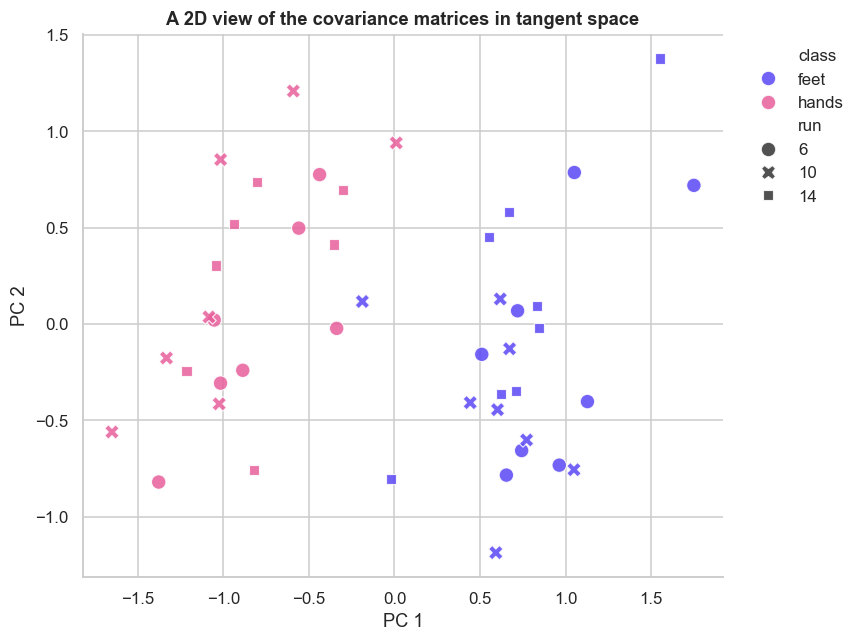

> **Figure takeaway:** the tangent map turns covariance matrices into ordinary feature vectors; this 2D projection is only a view of the full 153-feature representation.

In [28]:
# Purpose: Map covariance matrices to tangent vectors and display a 2D projection.

tangent_features = TangentSpace(metric="riemann").fit_transform(covariances)
coordinates = PCA(n_components=2, random_state=42).fit_transform(tangent_features)
embedding = pd.DataFrame(
    {
        "PC 1": coordinates[:, 0],
        "PC 2": coordinates[:, 1],
        "class": CLASS_NAMES[dataset.y],
        "run": dataset.metadata["run"].to_numpy(),
    }
)

fig, axis = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=embedding,
    x="PC 1",
    y="PC 2",
    hue="class",
    style="run",
    s=90,
    alpha=0.85,
    ax=axis,
)
axis.set_title("A 2D view of the covariance matrices in tangent space")
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()
display(Markdown(
    "> **Figure takeaway:** the tangent map turns covariance matrices "
    "into ordinary feature vectors; this 2D projection is only a view "
    "of the full 153-feature representation."
))

## 8. Reuse the workflow on your own EEG

The reusable pattern is short:

```python
# X shape: (trials, channels, time samples)
# y shape: (trials,)
# groups: session, run, or participant identity for honest validation

pipeline = Pipeline([
    ("covariance", Covariances(estimator="oas")),
    ("tangent", TangentSpace(metric="riemann")),
    ("classifier", LogisticRegression(class_weight="balanced")),
])

for train, test in LeaveOneGroupOut().split(X, y, groups):
    pipeline.fit(X[train], y[train])
    predictions = pipeline.predict(X[test])
```

Before this code, your MNE workflow should:

1. Load `Raw` EEG and set correct channel locations.
2. Mark or remove artifacts.
3. Filter for frequencies justified by the task.
4. Create cue-aligned `Epochs`.
5. Keep a group label for every participant, session, or run that must
   remain independent at test time.

## Common mistakes

- **Leakage:** fitting CSP, a tangent reference point, or any scaler
  before cross-validation lets test information enter training.
- **Random trial splitting:** this can mix trials from the same recording
  block across train and test.
- **Singular covariance matrices:** too many channels or too few samples
  can produce unstable estimates; use regularization and inspect matrix
  rank.
- **Unjustified filtering:** frequency bands should follow the
  neurophysiology and task, not only the score.
- **One-participant conclusions:** subject-specific success does not
  establish cross-participant generalization.
- **No baseline:** geometry should be compared with a credible standard
  method such as CSP for motor imagery.

## Exercises: change one thing and re-run

These are the point of the notebook. Reading it shows you the workflow;
changing one variable and predicting the result is what turns it into
something you can use. Each exercise below runs — a knob is marked with
`# <- change this`, and a folded note tells you what to look for after
you have made your own prediction.

Keep the held-out-run validation fixed and change exactly one thing at a
time. That is the whole discipline of a credible BCI experiment, in
miniature.

In [29]:
# Purpose: Exercises: define a shared metric-generic MDM evaluator.

# A shared evaluator, so every exercise below changes ONE thing against
# the same leakage-safe protocol. It is deliberately explicit: the class
# centers are built from the training runs only.
def evaluate_mdm(matrices, labels, groups, mean_fn, dist_fn):
    fold_scores = []
    for train, test in LeaveOneGroupOut().split(matrices, labels, groups):
        centers = {
            k: mean_fn(matrices[train][labels[train] == k])
            for k in np.unique(labels)
        }
        predictions = np.array([
            min(centers, key=lambda k: dist_fn(centers[k], m))
            for m in matrices[test]
        ])
        recalls = [
            (predictions[labels[test] == k] == k).mean()
            for k in np.unique(labels)
        ]
        fold_scores.append(float(np.mean(recalls)))
    return np.array(fold_scores)

from pyriemann.utils.mean import mean_logeuclid
from pyriemann.utils.distance import distance_logeuclid

### 1. How few electrodes can you get away with?

Motor imagery is generated over the central strip — `C3`, `Cz`, `C4` sit
right on top of it. The notebook used seventeen channels. Before you run
the next cell: keeping only those three, do you expect the score to
collapse, drop a little, or hold?

<details><summary>What to look for.</summary>

Three channels score around **0.91** against the full seventeen at
**0.98**. The motor strip alone carries most of the signal — a useful
thing to know when you are choosing a cheaper headset — but the extra
electrodes still buy a real, measurable margin. "Fewer channels" is a
trade, not a free lunch.

</details>

In [30]:
# Purpose: Exercise 1: rerun with only the three central-strip electrodes.

motor_strip = ["C3", "Cz", "C4"]  # <- change this list
keep = [dataset.channel_names.index(ch) for ch in motor_strip]

subset_cov = Covariances(estimator="oas").fit_transform(
    dataset.X[:, keep, :]
)
subset_scores = evaluate_mdm(
    subset_cov, dataset.y, dataset.groups, mean_riemann, distance_riemann
)
full_scores = evaluate_mdm(
    covariances, dataset.y, dataset.groups, mean_riemann, distance_riemann
)
print(f"{len(motor_strip):2d} channels : {subset_scores.mean():.3f}")
print(f"17 channels : {full_scores.mean():.3f}")

 3 channels : 0.911
17 channels : 0.979


### 2. Does the shrinkage actually matter?

Every covariance in this notebook used `estimator="oas"` — a regularized
estimate that pulls the matrix toward a scaled identity. The plain sample
covariance is `estimator="scm"`. With seventeen channels and a few
hundred samples per trial you might expect them to agree. Run the cell
and see.

<details><summary>What to look for.</summary>

The sample covariance **fails** — pyRiemann refuses it as not positive
definite. The reason is subtle and worth keeping: the notebook uses an
**average reference**, which subtracts the mean across channels and so
removes one degree of freedom. That makes every raw sample covariance
rank-deficient (rank 16 of 17), with a zero eigenvalue, and the
Riemannian mean cannot take the logarithm of a singular matrix. Shrinkage
is not a cosmetic default here; it is what keeps the whole pipeline
numerically alive.

</details>

In [31]:
# Purpose: Exercise 2: compare OAS shrinkage with the plain sample covariance.

import warnings

for estimator in ["oas", "scm"]:  # <- oas = shrinkage, scm = plain sample
    try:
        # The scm failure trips a "log of a non-positive matrix" warning
        # on the way to the error; silence it so the FAILED line is the
        # signal, not the noise.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            cov = Covariances(estimator=estimator).fit_transform(dataset.X)
            scores = evaluate_mdm(
                cov, dataset.y, dataset.groups,
                mean_riemann, distance_riemann,
            )
        print(f"{estimator}: {scores.mean():.3f}")
    except Exception as error:
        print(f"{estimator}: FAILED -- {type(error).__name__}")

one_cov = np.cov(dataset.X[0])
print(
    f"\none sample covariance: rank "
    f"{np.linalg.matrix_rank(one_cov)} of {one_cov.shape[0]}, "
    f"smallest eigenvalue {np.linalg.eigvalsh(one_cov).min():.2e}"
)

oas: 0.979
scm: FAILED -- ValueError

one sample covariance: rank 16 of 17, smallest eigenvalue -1.88e-26


### 3. A different curved ruler

The affine-invariant metric is not the only geometry on covariance
matrices. The **log-Euclidean** metric maps every matrix to its logarithm
once, then measures ordinary straight-line distance there. It is faster
and keeps the swelling fix, but it gives up full affine invariance. Swap
it in and see how much the accuracy actually depends on that.

<details><summary>What to look for.</summary>

The two are close — affine-invariant around **0.98**, log-Euclidean
around **0.96** here. On same-session data, where there is no large
recording shift to be invariant to, the cheaper metric costs almost
nothing. The gap tends to open up in exactly the transfer settings that
Section 5b was about, which is the honest way to choose between them:
match the metric to whether invariance is doing any work for your data.

</details>

In [32]:
# Purpose: Exercise 3: swap the affine-invariant metric for log-Euclidean.

for name, mean_fn, dist_fn in [
    ("affine-invariant", mean_riemann, distance_riemann),
    ("log-Euclidean", mean_logeuclid, distance_logeuclid),  # <- the swap
]:
    scores = evaluate_mdm(
        covariances, dataset.y, dataset.groups, mean_fn, dist_fn
    )
    print(f"{name:16s}: {scores.mean():.3f} +/- {scores.std():.3f}")

affine-invariant: 0.979 +/- 0.029
log-Euclidean   : 0.955 +/- 0.063


### More to try on your own

No solutions for these — they are open questions, and the two optional
appendices below give you a starting point for the first one.

- **Change the epoch window** (`tmin`, `tmax` when the data is loaded) and
  justify the choice from the motor-imagery time course, not the score.
- **Add participants** and use participant identity as the validation
  group. Cross-participant prediction is much harder than cross-run;
  the appendix immediately below sets it up.
- **Recenter across participants**, not just runs, and see whether the
  alignment from Section 5b earns its keep when the sessions really are
  different people.

## Optional extension: test generalization across participants

The default result is intentionally scoped to one participant. It is
useful for learning the workflow, but it cannot establish that a model
generalizes to a new person.

To study that harder question:

```python
dataset = load_motor_imagery(subjects=(1, 2, 3, 4, 5), ...)
participant_groups = dataset.metadata["subject"].to_numpy()
scores, predictions = evaluate_leave_one_group_out(
    pipelines, dataset.X, dataset.y, participant_groups
)
```

This holds out all trials from one participant at a time. Expect lower
performance: anatomy, electrode placement, strategy, and recording
conditions differ between people. Alignment and transfer-learning
methods should be evaluated inside the same held-out-participant
protocol.

## Optional: discover the same dataset through EEGDash

**Decision for this notebook: complement, not replace.** The direct MNE
loader above is smaller and simpler for a first run. EEGDash becomes
useful when you want BIDS metadata, consistent discovery, and a path to
many other MNE/braindecode-compatible datasets.

The following snippet was tested with EEGDash 0.8.3. It queries metadata
first, then downloads only subject 001, run 6 when `raw` is accessed:

```python
# Optional dependency: pip install eegdash
from eegdash import EEGDash, EEGDashDataset

records = EEGDash().find(
    dataset="ds004362",
    subject="001",
    run="6",
    limit=1,
)
eegdash_dataset = EEGDashDataset(
    cache_dir="./data/eegdash",
    records=records,
)
raw = eegdash_dataset.datasets[0].raw
print(raw.info["sfreq"], len(raw.ch_names))
```

Keep dataset loading separate from the validation logic: subject,
session, and run identifiers from BIDS metadata should become grouping
variables rather than being randomly mixed across folds.

## Sources and further reading

- [MNE EEGBCI dataset loader](https://mne.tools/stable/generated/mne.datasets.eegbci.load_data.html)
- [MNE motor-imagery CSP example](https://mne.tools/stable/auto_examples/decoding/decoding_csp_eeg.html)
- [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/)
- [pyRiemann MDM documentation](https://pyriemann.readthedocs.io/en/latest/generated/pyriemann.classification.MDM.html)
- Barachant et al. (2012),
  [Multiclass Brain-Computer Interface Classification by Riemannian Geometry](https://doi.org/10.1109/TBME.2011.2172210)
- Barachant et al. (2013),
  [Classification of covariance matrices using a Riemannian-based kernel](https://doi.org/10.1016/j.neucom.2012.12.039)
- Congedo, Barachant & Bhatia (2017),
  [Riemannian geometry for EEG-based brain-computer interfaces; a primer and a review](https://doi.org/10.1080/2326263X.2017.1297192)
- Zanini et al. (2018),
  [Transfer learning: a Riemannian geometry framework with applications to BCI](https://doi.org/10.1109/TBME.2017.2742541)
- Barthélemy et al. (2019),
  [The Riemannian Potato Field: a tool for online signal quality index of EEG](https://doi.org/10.1109/TNSRE.2019.2893113)
- Andreev, Cattan & Congedo (2025),
  [The Riemannian Means Field classifier for EEG-based BCI data](https://arxiv.org/abs/2504.17352)

Dataset citation: Schalk et al. (2004), *BCI2000: A General-Purpose
Brain-Computer Interface (BCI) System*, IEEE Transactions on Biomedical
Engineering.